In [1]:
import os
import json
import pickle
import argparse
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import tgt
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
)
import gc
gc.collect()
torch.cuda.empty_cache()
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

class GumbelQuantizerEMA(nn.Module):
    def __init__(self, input_dim: int, num_vars: int = 320,
                 temp: float = 2.0, decay: float = 0.99):
        super().__init__()
        self.num_vars = num_vars
        self.temp     = temp
        self.decay    = decay

        self.weight_proj = nn.Linear(input_dim, num_vars)

        self.register_buffer("codevectors", torch.randn(num_vars, input_dim))
        self.register_buffer("cluster_size", torch.ones(num_vars))
        self.register_buffer("ema_embed",   torch.randn(num_vars, input_dim))
        nn.init.uniform_(self.codevectors, -1.0, 1.0)

    def forward(self, X: torch.Tensor):
        B, T, D = X.shape
        logits   = self.weight_proj(X)

        if self.training:
            probs = F.gumbel_softmax(logits, tau=self.temp, hard=True)

            with torch.no_grad():
                flat_probs = probs.reshape(-1, self.num_vars)
                flat_X     = X.reshape(-1, D)
                counts     = flat_probs.sum(0)
                embed_sum  = flat_probs.T @ flat_X

                self.cluster_size = (self.decay * self.cluster_size
                                     + (1 - self.decay) * counts)
                self.ema_embed    = (self.decay * self.ema_embed
                                     + (1 - self.decay) * embed_sum)
                self.codevectors  = (self.ema_embed
                                     / self.cluster_size.unsqueeze(1).clamp(min=1e-5))
        else:
            indices = logits.argmax(dim=-1)
            probs   = F.one_hot(indices, self.num_vars).float()

        quantized = torch.matmul(probs, self.codevectors)
        return quantized, probs
# =========================
# Step 9: Model
# =========================
"""
class Wav2Vec2ForCTC_FS_REC(nn.Module):
    def __init__(self, base_model, vocab_size, hidden_dim,
                 ctc_tokenizer, n_negatives=50, temperature=0.1):
        super().__init__()
        self.wav2vec2            = base_model.wav2vec2
        self.ctc_head            = base_model.lm_head
        self.ctc_tokenizer       = ctc_tokenizer
        self.n_negatives         = n_negatives
        self.temperature         = temperature
        self.align_temperature   = 5.0                              # ← must match training
        self.fx                  = nn.Linear(hidden_dim, hidden_dim, bias=False)  # ← no bias
        self.quantizer           = GumbelQuantizerEMA(input_dim=hidden_dim)
        self.reconstruction_head = nn.Linear(2 * hidden_dim, hidden_dim)

    def _ctc_decode_batch(self, logits):
        pred_ids  = logits.argmax(dim=-1)
        sequences = []
        for seq in pred_ids:
            unique_mask = torch.cat([
                torch.tensor([True], device=seq.device),
                seq[1:] != seq[:-1]
            ])
            collapsed = seq[unique_mask]
            collapsed = collapsed[collapsed != 0]
            if collapsed.numel() == 0:
                collapsed = torch.tensor([1], device=seq.device)
            sequences.append(collapsed)
        return torch.nn.utils.rnn.pad_sequence(
            sequences, batch_first=True, padding_value=0
        )

    def compute_phoneme_embeddings_from_ctc(self, X, logits, labels_clean):
        B, T, D   = X.shape
        ctc_probs = logits.softmax(dim=-1)
        Y_emb_list = []
        for b in range(B):
            phone_embs = []
            for p_id in labels_clean[b]:
                p_id = p_id.item()
                if p_id == 0:
                    phone_embs.append(torch.zeros(D, device=X.device))
                    continue
                weights = ctc_probs[b, :, p_id]
                weight_sum = weights.sum()
                if weight_sum < 1e-6:
                    weights = torch.ones_like(weights) / weights.shape[0]
                else:
                    weights = weights / weight_sum
                emb = (weights.unsqueeze(-1) * X[b]).sum(0)
                phone_embs.append(emb)
            Y_emb_list.append(torch.stack(phone_embs))
        return torch.stack(Y_emb_list)

    def compute_alignment(self, X, Y_emb):
        B, T, D = X.shape
        _, N, _ = Y_emb.shape
        X_proj  = self.fx(X)
        X_norm  = F.normalize(X_proj, dim=-1)
        Y_norm  = F.normalize(Y_emb,  dim=-1)
        D_mat   = self.align_temperature * torch.matmul(
            Y_norm, X_norm.transpose(1, 2)
        )
        n_idx = torch.arange(N, device=X.device).float() / max(N - 1, 1)
        t_idx = torch.arange(T, device=X.device).float() / max(T - 1, 1)
        avg_frames_per_phone = T / max(N, 1)
        prior_weight = min(10.0, 2.0 * avg_frames_per_phone)
        prior = -prior_weight * (n_idx.unsqueeze(1) - t_idx.unsqueeze(0)) ** 2

        D_mat = D_mat + prior.unsqueeze(0)
        return torch.softmax(D_mat, dim=1)

    def forward(self, input_values, attention_mask=None):
        outputs      = self.wav2vec2(input_values, attention_mask=attention_mask)
        X            = outputs.last_hidden_state
        logits       = self.ctc_head(X)
        with torch.no_grad():
            labels_clean = self._ctc_decode_batch(logits)
        Y_emb = self.compute_phoneme_embeddings_from_ctc(
            X.detach(), logits.detach(), labels_clean
        )
        A = self.compute_alignment(X, Y_emb)
        return logits, A, labels_clean
"""

##### joint_nofxfy
import torch
import torch.nn as nn
import torch.nn.functional as F
from types import SimpleNamespace
class GumbelQuantizerEMA(nn.Module):
    def __init__(self, input_dim: int, num_vars: int = 320,
                 temp: float = 2.0, decay: float = 0.99):
        super().__init__()
        self.num_vars = num_vars
        self.temp     = temp
        self.decay    = decay

        self.weight_proj = nn.Linear(input_dim, num_vars)

        self.register_buffer("codevectors", torch.randn(num_vars, input_dim))
        self.register_buffer("cluster_size", torch.ones(num_vars))
        self.register_buffer("ema_embed",   torch.randn(num_vars, input_dim))
        nn.init.uniform_(self.codevectors, -1.0, 1.0)

    def forward(self, X: torch.Tensor):
        B, T, D = X.shape
        logits   = self.weight_proj(X)

        if self.training:
            probs = F.gumbel_softmax(logits, tau=self.temp, hard=True)

            with torch.no_grad():
                flat_probs = probs.reshape(-1, self.num_vars)
                flat_X     = X.reshape(-1, D)
                counts     = flat_probs.sum(0)
                embed_sum  = flat_probs.T @ flat_X

                self.cluster_size = (self.decay * self.cluster_size
                                     + (1 - self.decay) * counts)
                self.ema_embed    = (self.decay * self.ema_embed
                                     + (1 - self.decay) * embed_sum)
                self.codevectors  = (self.ema_embed
                                     / self.cluster_size.unsqueeze(1).clamp(min=1e-5))
        else:
            indices = logits.argmax(dim=-1)
            probs   = F.one_hot(indices, self.num_vars).float()

        quantized = torch.matmul(probs, self.codevectors)
        return quantized, probs
# =========================
# Step 9: Model
# =========================

class Wav2Vec2ForCTC_FS_REC(nn.Module):
    def __init__(self, base_model, vocab_size, hidden_dim,
                 ctc_tokenizer, n_negatives=50, temperature=0.1):
        super().__init__()
        self.wav2vec2            = base_model.wav2vec2
        self.ctc_head            = base_model.lm_head
        self.ctc_tokenizer       = ctc_tokenizer
        self.n_negatives         = n_negatives
        self.temperature         = temperature
        self.align_temperature   = 5.0                              # ← must match training
        self.fx                  = nn.Linear(hidden_dim, hidden_dim, bias=False)  # ← no bias
        self.quantizer           = GumbelQuantizerEMA(input_dim=hidden_dim)
        self.reconstruction_head = nn.Linear(2 * hidden_dim, hidden_dim)

    def _ctc_decode_batch(self, logits):
        pred_ids  = logits.argmax(dim=-1)
        sequences = []
        for seq in pred_ids:
            unique_mask = torch.cat([
                torch.tensor([True], device=seq.device),
                seq[1:] != seq[:-1]
            ])
            collapsed = seq[unique_mask]
            collapsed = collapsed[collapsed != 0]
            if collapsed.numel() == 0:
                collapsed = torch.tensor([1], device=seq.device)
            sequences.append(collapsed)
        return torch.nn.utils.rnn.pad_sequence(
            sequences, batch_first=True, padding_value=0
        )

    def compute_phoneme_embeddings_from_ctc(self, X, logits, labels_clean):
        B, T, D   = X.shape
        ctc_probs = logits.softmax(dim=-1)
        Y_emb_list = []
        for b in range(B):
            phone_embs = []
            for p_id in labels_clean[b]:
                p_id = p_id.item()
                if p_id == 0:
                    phone_embs.append(torch.zeros(D, device=X.device))
                    continue
                weights = ctc_probs[b, :, p_id]
                weight_sum = weights.sum()
                if weight_sum < 1e-6:
                    weights = torch.ones_like(weights) / weights.shape[0]
                else:
                    weights = weights / weight_sum
                emb = (weights.unsqueeze(-1) * X[b]).sum(0)
                phone_embs.append(emb)
            Y_emb_list.append(torch.stack(phone_embs))
        return torch.stack(Y_emb_list)

    def compute_alignment(self, X, Y_emb):
        B, T, D = X.shape
        _, N, _ = Y_emb.shape
        X_proj  = self.fx(X)
        X_norm  = F.normalize(X_proj, dim=-1)
        Y_norm  = F.normalize(Y_emb,  dim=-1)
        D_mat   = self.align_temperature * torch.matmul(
            Y_norm, X_norm.transpose(1, 2)
        )
        n_idx = torch.arange(N, device=X.device).float() / max(N - 1, 1)
        t_idx = torch.arange(T, device=X.device).float() / max(T - 1, 1)
        prior = -10.0 * (n_idx.unsqueeze(1) - t_idx.unsqueeze(0)) ** 2
        D_mat = D_mat + prior.unsqueeze(0)
        return torch.softmax(D_mat, dim=1)

    def forward(self, input_values, attention_mask=None):
        outputs      = self.wav2vec2(input_values, attention_mask=attention_mask)
        X            = outputs.last_hidden_state
        logits       = self.ctc_head(X)
    
        with torch.no_grad():
            labels_clean = self._ctc_decode_batch(logits)
    
        Y_emb = self.compute_phoneme_embeddings_from_ctc(
            X.detach(), logits.detach(), labels_clean
        )
        A = self.compute_alignment(X, Y_emb)
    
        # Return object with .logits so evaluate_per.py works unchanged
        return {
            "logits":       logits,
            "alignment":    A,
            "labels_clean": labels_clean,
        }

/home/imbenamor/miniconda3/envs/venv-test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import AutoModel,AutoTokenizer

# =========================
# Corpus-label → IPA mapping (must match training)
# =========================
YOUR_TO_IPA = {
    "a":  "a",  "b":  "b",  "d":  "d",
    "e":  "e",  "f":  "f",  "i":  "i",  "j":  "j",
    "k":  "k",  "l":  "l",  "m":  "m",  "n":  "n",
    "o":  "o",  "p":  "p",  "s":  "s",  "t":  "t",
    "u":  "u",  "v":  "v",  "w":  "w",  "y":  "y",
    "z":  "z",  "ø":  "ø",  "ŋ":  "ŋ",  "ɔ":  "ɔ",
    "ə":  "ə",  "ɛ":  "ɛ",  "ɡ":  "ɡ",  "ɲ":  "ɲ",
    "ʁ":  "ʁ",  "ʃ":  "ʃ",  "ʒ":  "ʒ",
    "dʒ": "ʒ",  "tʃ": "ʃ",  "ts": "s",  "@":  "ə",
    "§":     None,
    "*":     None,
    "[PAD]": None,
    "[UNK]": None,
}


# =========================
# Inference model
# =========================
class Wav2Vec2ForCTC_FS_REC_Inference(nn.Module):
    """
    Inference-only version of the BERTphone model.
    Holds:
      - Wav2Vec2 encoder + CTC head  (loaded from checkpoint)
      - XPhoneBERT + bert_proj       (BERT frozen, proj from checkpoint)
      - fx alignment projection      (loaded from checkpoint)
      - compute_alignment with gaussian + ahead_penalty prior

    Drops: quantizer, reconstruction_head (training-only).
    Returns: {"logits", "alignment", "labels_clean"}.
    """

    def __init__(
        self,
        base_model:    Wav2Vec2ForCTC,
        ctc_tokenizer,
        hidden_dim:    int,
        align_temperature: float = 15.0,
        diag_strength:     float = 30.0,
        ahead_strength:    float = 40.0,
    ):
        super().__init__()
        self.wav2vec2      = base_model.wav2vec2
        self.ctc_head      = base_model.lm_head
        self.ctc_tokenizer = ctc_tokenizer
        self.align_temperature = align_temperature
        self.diag_strength     = diag_strength
        self.ahead_strength    = ahead_strength

        print("Loading XPhoneBERT ...")
        self.phoneme_bert   = AutoModel.from_pretrained("vinai/xphonebert-base")
        self.xphonebert_tok = AutoTokenizer.from_pretrained(
            "vinai/xphonebert-base", add_prefix_space=True
        )
        for p in self.phoneme_bert.parameters():
            p.requires_grad = False

        self.bert_proj = nn.Sequential(
            nn.Linear(768, hidden_dim),
            nn.ReLU(),
        )
        self.fx = nn.Linear(hidden_dim, hidden_dim, bias=False)
        nn.init.eye_(self.fx.weight)

    # ------------------------------------------------------------------
    def _ctc_decode_batch(self, logits: torch.Tensor) -> torch.Tensor:
        pred_ids  = logits.argmax(dim=-1)
        sequences = []
        for seq in pred_ids:
            unique_mask = torch.cat([
                torch.tensor([True], device=seq.device),
                seq[1:] != seq[:-1]
            ])
            collapsed = seq[unique_mask]
            collapsed = collapsed[collapsed != 0]
            if collapsed.numel() == 0:
                collapsed = torch.tensor([1], device=seq.device)
            sequences.append(collapsed)
        return torch.nn.utils.rnn.pad_sequence(
            sequences, batch_first=True, padding_value=0
        )

    # ------------------------------------------------------------------
    def decode_to_ipa(self, labels_clean: torch.Tensor) -> list:
        ipa_sequences = []
        for seq in labels_clean:
            ipa_phones = []
            for token_id in seq:
                tid = token_id.item()
                if tid == 0:
                    break
                corpus_label = self.ctc_tokenizer.convert_ids_to_tokens(tid)
                ipa          = YOUR_TO_IPA.get(corpus_label, None)
                if ipa is not None:
                    ipa_phones.append(ipa)
            if not ipa_phones:
                ipa_phones = ["ə"]
            ipa_sequences.append(ipa_phones)
        return ipa_sequences

    # ------------------------------------------------------------------
    def compute_phoneme_embeddings(self, labels_clean, device):
        ipa_sequences = self.decode_to_ipa(labels_clean)
        bert_inputs   = self.xphonebert_tok(
            ipa_sequences,
            return_tensors      = "pt",
            padding             = True,
            is_split_into_words = True,
        ).to(device)
        with torch.no_grad():
            bert_out = self.phoneme_bert(**bert_inputs)
        H_bert  = bert_out.last_hidden_state[:, 1:-1, :]      # drop CLS/SEP
        N_clean = (labels_clean != 0).sum(dim=-1).max().item()
        N_bert  = H_bert.shape[1]
        if N_bert >= N_clean:
            H_bert = H_bert[:, :N_clean, :]
        else:
            pad    = torch.zeros(H_bert.shape[0], N_clean - N_bert, 768,
                                 device=device, dtype=H_bert.dtype)
            H_bert = torch.cat([H_bert, pad], dim=1)
        return self.bert_proj(H_bert)

    # ------------------------------------------------------------------
    def compute_alignment(self, X: torch.Tensor, Y_emb: torch.Tensor) -> torch.Tensor:
        print(f"X.shape={tuple(X.shape)}  Y_emb.shape={tuple(Y_emb.shape)}")
        print(f"align_temperature={self.align_temperature} (type={type(self.align_temperature).__name__})")
        B, T, D = X.shape
        _, N, _ = Y_emb.shape
        X_proj = self.fx(X)
        X_norm = F.normalize(X_proj, dim=-1)
        Y_norm = F.normalize(Y_emb,  dim=-1)
        D_mat  = self.align_temperature * torch.matmul(
            Y_norm, X_norm.transpose(1, 2)
        )
        n_idx = torch.arange(N, device=X.device).float() / max(N - 1, 1)
        t_idx = torch.arange(T, device=X.device).float() / max(T - 1, 1)
        diff          = n_idx.unsqueeze(1) - t_idx.unsqueeze(0)
        gaussian      = -self.diag_strength  * diff ** 2
        ahead_penalty = -self.ahead_strength * torch.clamp(diff, min=0) ** 2
        prior         = gaussian + ahead_penalty
        D_mat         = D_mat + prior.unsqueeze(0)
        return torch.softmax(D_mat, dim=1)

    # ------------------------------------------------------------------
    def forward(self, input_values, attention_mask=None):
        outputs      = self.wav2vec2(input_values, attention_mask=attention_mask)
        X            = outputs.last_hidden_state
        logits       = self.ctc_head(X)
        labels_clean = self._ctc_decode_batch(logits)
        Y_emb        = self.compute_phoneme_embeddings(labels_clean, device=X.device)
        A            = self.compute_alignment(X, Y_emb)
        return {
            "logits":       logits,
            "alignment":    A,
            "labels_clean": labels_clean,
        }


In [3]:
sampa_to_api_single = {
    # vowels
    'a': 'a',      # (ignore 'ɑ' duplicate → keep simple)
    'e': 'e',
    'i': 'i',
    'o': 'o',
    'u': 'u',
    'y': 'y',

    '2': 'ø',
    '9': '9',      # œ
    '@': 'ə',
    'E': 'ɛ',
    'O': 'ɔ',

    # nasal vowels
    'a~': '@',     # ɑ̃
    'e~': '5',     # ɛ̃
    '9~': '1',     # œ̃ / ɛ̃
    'o~': '§',     # ɔ̃

    # consonants
    'b': 'b',
    'd': 'd',
    'f': 'f',
    'g': 'ɡ',
    'k': 'k',
    'l': 'l',
    'm': 'm',
    'n': 'n',
    'n=':'n',
    'p': 'p',
    't': 't',
    'v': 'v',
    'w': 'w',
    'z': 'z',
    'j': 'j',

    # special consonants
    'R': 'ʁ',
    'N': 'ŋ',
    'H': 'ɥ',

    # palatal / special
    'J': 'ɲ',      # prefer ɲ over ɟ (French consistent)
    'S': 'ʃ',      # prefer fricative over affricate
    'Z': 'ʒ',
    'Z=': 'ʒ',

    # affricates (if explicitly needed)
    's': 's',

    # special cases from your table
    'm=': 'm',

    # silence / noise
    '_': '_',
    'spn': 'spn',
    'unk': 'spn',
    "%":'spn',
    "?":"spn",
    "0":"spn"
}
hyp_to_ref = {
    **sampa_to_api_single,
    '@': '@',    # override: vocab '@' is the nasal vowel, not schwa
    'ts': 's',    # ADD — model sometimes outputs affricate, collapse to /s/
    'tʃ': 'ʃ'
}
def normalise_hyp_token(tok: str) -> str:
    """Convert a raw tokenizer token to the REF label space."""
    return hyp_to_ref.get(tok, tok)   # passthrough if not in map
def map_ref_to_api_single(ph, mapping):
    if ph in mapping:
        return mapping[ph]
    if ph is not None and ph != "":
        return ph
    return None


In [4]:
with open("vocab_w2vCTC-woSIL.json") as f:
    vocab = json.load(f)
print("Tokens:", sorted(vocab.keys()))
print("Number of tokens:", len(vocab))

Tokens: ['1', '5', '9', '@', '[PAD]', '[UNK]', 'a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 's', 't', 'ts', 'tʃ', 'u', 'v', 'w', 'y', 'z', '§', 'ø', 'ŋ', 'ɔ', 'ə', 'ɛ', 'ɡ', 'ɲ', 'ʁ', 'ʃ', 'ʒ']
Number of tokens: 40


In [5]:
def read_textgrid(tg_path, tier_name="phone"):
    """
    Returns list of {'phoneme': str, 'start': float, 'end': float}.
    Skips silence intervals (empty label, SIL, sil, sp).
    """
    tg        = tgt.io.read_textgrid(tg_path)
    tier      = tg.get_tier_by_name(tier_name)
    silence   = {"", "SIL", "sil", "spn", "SP", "<SIL>", "_","0","fe~","sjo~","Ra~"}
    intervals = []
    for iv in tier.intervals:
        label = iv.text.strip()
        phoneme=map_ref_to_api_single(label,sampa_to_api_single)
        if phoneme in silence:
            continue
        intervals.append({
            "phoneme": phoneme,
            "start":   round(iv.start_time, 6),
            "end":     round(iv.end_time,   6),
        })
        if phoneme==None:
            print(phoneme)
    return intervals


In [6]:

def _extract_boundaries_from_A(A_np: np.ndarray, N: int, T: int) -> list:
    if N == 0:
        return [0, T]
    if T < N:
        return list(range(N + 1))
    
    assignments = A_np.argmax(axis=0)
    for t in range(1, T):
        if assignments[t] < assignments[t - 1]:
            assignments[t] = assignments[t - 1]
    
    boundaries = [0]
    for n in range(1, N):
        frames = np.where(assignments == n)[0]
        if len(frames) > 0:
            # clamp: argmax can land before previous boundary
            boundaries.append(max(int(frames[0]), boundaries[-1] + 1))
        else:
            boundaries.append(boundaries[-1] + 1)
    
    boundaries.append(T)
    return boundaries



In [7]:

def extract_intervals_forced(logits, A, tokenizer, duration_sec: float,
                              frame_shift: float = 0.02) -> list:
    blank_id = tokenizer.pad_token_id
    pred_ids = logits[0].argmax(dim=-1).tolist()
    collapsed, collapsed_pos = [], []
    prev = None
    for t, tok in enumerate(pred_ids):
        if tok != prev:
            if tok != blank_id:
                collapsed.append(tok)
                collapsed_pos.append(t)
        prev = tok
    if not collapsed:
        return []

    N    = len(collapsed)
    A_np = A[0, :N, :].cpu().float().numpy()
    T    = A_np.shape[1]

    # Speech onset
    min_run = 2
    run, first_speech_frame = 0, collapsed_pos[0]
    for t, tok in enumerate(pred_ids):
        if tok != blank_id:
            run += 1
            if run >= min_run:
                first_speech_frame = t - (min_run - 1)
                break
        else:
            run = 0

    boundaries = _extract_boundaries_from_A(A_np, N, T)

    skip = {"[PAD]", "[UNK]", "spn", "", None}
    intervals = []
    for n in range(N):
        raw_tok     = tokenizer.convert_ids_to_tokens(collapsed[n])
        phoneme_str = normalise_hyp_token(raw_tok)
        if phoneme_str not in skip:
            intervals.append({
                "phoneme": phoneme_str,
                "start":   round(boundaries[n]     * frame_shift, 6),
                "end":     round(boundaries[n + 1] * frame_shift, 6),
            })

    if intervals:
        # Fix first interval start using speech onset
        onset        = round(first_speech_frame * frame_shift, 6)
        min_duration = frame_shift
        safe_start   = min(onset, intervals[0]["end"] - min_duration)
        intervals[0]["start"] = max(0.0, safe_start)

        # Fix last interval end — clip to actual audio duration
        intervals[-1]["end"] = min(intervals[-1]["end"], duration_sec)

        # Guard: ensure last interval is still valid after clipping
        if intervals[-1]["end"] <= intervals[-1]["start"]:
            intervals[-1]["end"] = intervals[-1]["start"] + min_duration

    return intervals

In [14]:

audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected_withsilence/"
textgrid_dir = "/vol/corpora/Rhapsodie/TextGrid.phones.sampa/"
vocab = "vocab_w2vCTC-woSIL.json"
output="results/rhap_ctc_FS.pkl"
tier = "sampa"
device = "cuda"
align_temperature = 15.0
diag_strength = 30.0
ahead_strength= 40.0
print(f"Device: {device}")

# ── Processor ─────────────────────────────────────────────────────────
tokenizer = Wav2Vec2CTCTokenizer(
    vocab_file           = vocab,
    unk_token            = "[UNK]",
    pad_token            = "[PAD]",
    word_delimiter_token = "",
)
feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size         = 1,
    sampling_rate        = 16000,
    padding_value        = 0.0,
    do_normalize         = True,
    return_attention_mask = True,
)
print("Loading processor...")
tokenizer = Wav2Vec2CTCTokenizer(
    vocab_file=vocab,
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token="",
)
feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size=1,
    sampling_rate=16000,
    padding_value=0.0,
    do_normalize=True,
    return_attention_mask=True,
)
processor = Wav2Vec2Processor(
    feature_extractor=feature_extractor, tokenizer=tokenizer
)
#checkpoint = "results/w2vCTC_FS_normalized/checkpoint-7811"
checkpoint = "results/w2vCTC_joint_nofxfy/checkpoint-21092"
#checkpoint = "results/w2vCTC_bertphone/checkpoint-14841"
ctc_checkpoint = "results/w2vCTC/checkpoint-23430"
# ── Model ─────────────────────────────────────────────────────────────
print(f"Loading CTC architecture from {ctc_checkpoint}...")
base_model = Wav2Vec2ForCTC.from_pretrained(
    ctc_checkpoint,
    ctc_loss_reduction = "mean",
    ctc_zero_infinity  = True,
    pad_token_id       = tokenizer.pad_token_id,
    vocab_size         = len(tokenizer),
)
model = Wav2Vec2ForCTC_FS_REC(
    base_model,
    vocab_size = len(processor.tokenizer),
    hidden_dim = base_model.config.hidden_size,
    ctc_tokenizer = processor.tokenizer,
)
"""model = Wav2Vec2ForCTC_FS_REC_Inference(
        base_model        = base_model,
        ctc_tokenizer     = tokenizer,
        hidden_dim        = base_model.config.hidden_size,
        align_temperature = align_temperature,
        diag_strength     = diag_strength,
        ahead_strength    = ahead_strength,
    )"""
model.wav2vec2.feature_extractor._freeze_parameters()

bin_path = os.path.join(checkpoint, "pytorch_model.bin")
sft_path = os.path.join(checkpoint, "model.safetensors")
if os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location="cpu")
elif os.path.exists(sft_path):
    from safetensors.torch import load_file
    state_dict = load_file(sft_path)
else:
    raise FileNotFoundError(
        f"No model weights found in {checkpoint}\n"
        f"Expected pytorch_model.bin or model.safetensors"
    )

missing, unexpected = model.load_state_dict(state_dict, strict=False)

model.eval()
model.to(device)
print("Model ready.")



Device: cuda
Loading processor...
Loading CTC architecture from results/w2vCTC/checkpoint-23430...


Some weights of the model checkpoint at results/w2vCTC/checkpoint-23430 were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at results/w2vCTC/checkpoint-23430 and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN thi

Model ready.


In [15]:
audio_files = sorted(
    glob.glob(os.path.join(audio_dir, "**", "*.wav"), recursive=True)
)
audio_files[0]


'/vol/corpora/Rhapsodie/wav16k_corrected_withsilence/Rhap-D0002.wav'

In [16]:
import soundfile as sf

def get_ref_intervals(clean_ref, audio_path, eps=0.1):
    if not clean_ref:
        return []
    audio, sr = sf.read(audio_path)
    audio_duration = len(audio) / sr
    ref_first      = clean_ref[0]["start"]
    ref_last       = clean_ref[-1]["end"]
    end_overshoot  = ref_last - audio_duration
    ref_span       = ref_last - ref_first

    needs_correction = False
    reason = ""

    # Case 1: ref clearly extends past audio
    if end_overshoot > eps:
        needs_correction = True
        reason = "end_overshoot"
    # Case 2: ref starts well after 0 but its span fits within the audio
    elif ref_first > 0.3 and ref_span <= audio_duration + eps:
        needs_correction = True
        reason = "ref_first only"

    if needs_correction:
        offset = ref_first
        print(f"  Session offset corrected ({reason}): "
              f"ref_first={ref_first:.3f}s, ref_last={ref_last:.3f}s, "
              f"audio={audio_duration:.3f}s, end_overshoot={end_overshoot:+.3f}s, "
              f"offset={offset:.3f}s")
        return [
            {
                "phoneme": item["phoneme"],
                "start":   max(0.0, round(item["start"] - offset, 6)),
                "end":     max(0.0, round(item["end"]   - offset, 6)),
            }
            for item in clean_ref
        ]
    else:
        return list(clean_ref)

In [17]:
from collections import Counter
from VAD_chunk import vad_chunk_with_timestamps_v2
results = {}
n_done  = 0

for audio_path in os.listdir(audio_dir):
    audio_path = audio_dir + audio_path
    filename   = os.path.splitext(os.path.basename(audio_path))[0]

    if filename == "Rhap-D2004":
        continue

    tg_path = os.path.join(textgrid_dir, filename + "-Pro.TextGrid")
    if not os.path.exists(tg_path):
        print(f"  [SKIP] No TextGrid for {filename}")
        continue

    clean_ref     = read_textgrid(tg_path, tier)
    ref_intervals = get_ref_intervals(clean_ref, audio_path)

    audio, sr = sf.read(audio_path)
    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    wav    = torch.from_numpy(audio.astype(np.float32))
    chunks = vad_chunk_with_timestamps_v2(wav, max_pause_duration=1.5)
    audio_duration = len(audio) / 16000
    covered = sum(c["end"] - c["start"] for c in chunks) if chunks else 0
    print(f"  VAD coverage: {covered:.1f}s / {audio_duration:.1f}s "
          f"({100*covered/audio_duration:.1f}%)")

    spn_count = sum(1 for iv in ref_intervals if iv["phoneme"] == "_")
    print(f"  Ref spn count: {spn_count} / {len(ref_intervals)}")
    # Fix 1: fallback chunk must include pad_start/pad_end
    if not chunks:
        duration = len(audio) / 16000
        chunks = [{
            "start":     0.0,
            "end":       duration,
            "pad_start": 0.0,
            "pad_end":   duration,
        }]

    # ── Per-chunk inference ───────────────────────────────────────────
    hyp_intervals = []
    a_matrices    = []
    all_logits    = []

    for chunk in chunks:
        start_sample = int(chunk["pad_start"] * 16000)
        end_sample   = int(chunk["pad_end"]   * 16000)
        chunk_audio  = audio[start_sample:end_sample]

        if len(chunk_audio) < 400:
            continue

        inputs = feature_extractor(
            chunk_audio, sampling_rate=16000,
            return_tensors="pt", return_attention_mask=True,
        )

        with torch.no_grad():
            outputs = model(
            inputs.input_values.to(device),
            inputs.attention_mask.to(device),
            )
            logits       = outputs["logits"]
            A            = outputs["alignment"]
            labels_clean = outputs["labels_clean"]


        dur = len(chunk_audio) / 16000.0
        ivs = extract_intervals_forced(logits, A, tokenizer, dur)
        dropped_boundary = 0
        true_start = chunk["start"]
        true_end   = chunk["end"]
        for iv in ivs:
            abs_start = round(iv["start"] + chunk["pad_start"], 6)
            abs_end   = round(iv["end"]   + chunk["pad_start"], 6)
            centre    = (abs_start + abs_end) / 2.0
            if not (true_start - 0.01 <= centre <= true_end + 0.01):
                dropped_boundary += 1
        
        if dropped_boundary:
            print(f"  Chunk boundary drop: {dropped_boundary} intervals")
        

        for iv in ivs:
            abs_start = round(iv["start"] + chunk["pad_start"], 6)
            abs_end   = round(iv["end"]   + chunk["pad_start"], 6)

            centre = (abs_start + abs_end) / 2.0
            if true_start - 0.01 <= centre <= true_end + 0.01:
                hyp_intervals.append({
                    "phoneme": normalise_hyp_token(iv["phoneme"]),
                    "start":   abs_start,
                    "end":     abs_end,
                })

        # Fix 3: store full A matrix — let diagnose_file slice as needed
        a_matrices.append(A[0].cpu())
        all_logits.append(logits.cpu())


    total_ctc_phones = sum(
    len([t for t in logits[0].argmax(-1).tolist()
         if t != tokenizer.pad_token_id])  # raw non-blank count
    for logits in all_logits)
    print(f"  Raw CTC non-blank frames: {total_ctc_phones}, "
      f"hyp intervals: {len(hyp_intervals)}, "
      f"ref: {len(ref_intervals)}")
    results[filename] = {
        "file":          os.path.basename(audio_path),
        "ref_intervals": ref_intervals,
        "hyp_intervals": hyp_intervals,
        "A_chunks":      a_matrices,
        "logits_chunks": all_logits,
    }

    n_done += 1
    print(f"[{n_done}] Done: {filename}  "
          f"({len(hyp_intervals)} hyp intervals, {len(ref_intervals)} ref intervals)")
with open(output, "wb") as f:
    pickle.dump(results,f)

Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master


  VAD coverage: 16.8s / 22.3s (75.5%)
  Ref spn count: 0 / 166
  Chunk boundary drop: 1 intervals
  Chunk boundary drop: 12 intervals
  Raw CTC non-blank frames: 240, hyp intervals: 152, ref: 166
[1] Done: Rhap-M0012  (152 hyp intervals, 166 ref intervals)


Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master


  VAD coverage: 25.7s / 26.2s (98.4%)
  Ref spn count: 0 / 243
  Chunk boundary drop: 1 intervals
  Chunk boundary drop: 11 intervals
  Raw CTC non-blank frames: 334, hyp intervals: 224, ref: 243
[2] Done: Rhap-M0015  (224 hyp intervals, 243 ref intervals)


Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master


...

  VAD coverage: 182.3s / 182.3s (100.0%)
  Ref spn count: 0 / 2227
  Raw CTC non-blank frames: 3100, hyp intervals: 2214, ref: 2227
[51] Done: Rhap-D2013  (2214 hyp intervals, 2227 ref intervals)


Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master


  VAD coverage: 44.9s / 44.9s (100.0%)
  Ref spn count: 0 / 382
  Raw CTC non-blank frames: 580, hyp intervals: 377, ref: 382
[52] Done: Rhap-M0024  (377 hyp intervals, 382 ref intervals)


Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master


  VAD coverage: 380.3s / 386.2s (98.5%)
  Ref spn count: 0 / 3811
  Chunk boundary drop: 1 intervals
  Chunk boundary drop: 23 intervals
  Chunk boundary drop: 1 intervals
  Chunk boundary drop: 22 intervals
  Chunk boundary drop: 26 intervals
  Chunk boundary drop: 25 intervals
  Chunk boundary drop: 17 intervals
  Chunk boundary drop: 12 intervals
  Chunk boundary drop: 13 intervals
  Chunk boundary drop: 12 intervals
  Raw CTC non-blank frames: 5963, hyp intervals: 3708, ref: 3811
[53] Done: Rhap-M2002  (3708 hyp intervals, 3811 ref intervals)


In [18]:
import numpy as np
from typing import List, Dict, Tuple, Optional


# =============================================================================
# Step 1 — Edit distance alignment with traceback
# =============================================================================

def edit_distance_alignment(
    ref: List[str],
    hyp: List[str],
) -> List[Tuple[str, Optional[int], Optional[int]]]:
    """
    Align ref and hyp using edit distance.
    Returns a list of (operation, ref_idx, hyp_idx) tuples where operation is
    one of 'match', 'substitution', 'deletion', 'insertion'.
    ref_idx / hyp_idx are None when the operation has no counterpart.
    """
    N, M = len(ref), len(hyp)

    # ── DP table ─────────────────────────────────────────────────────────────
    dp = np.zeros((N + 1, M + 1), dtype=int)
    for i in range(N + 1):
        dp[i, 0] = i          # deletions
    for j in range(M + 1):
        dp[0, j] = j          # insertions

    for i in range(1, N + 1):
        for j in range(1, M + 1):
            if ref[i - 1] == hyp[j - 1]:
                dp[i, j] = dp[i - 1, j - 1]
            else:
                dp[i, j] = 1 + min(
                    dp[i - 1, j],      # deletion  (ref consumed, hyp not)
                    dp[i, j - 1],      # insertion (hyp consumed, ref not)
                    dp[i - 1, j - 1],  # substitution
                )

    # ── Traceback ─────────────────────────────────────────────────────────────
    alignment = []
    i, j = N, M
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref[i - 1] == hyp[j - 1]:
            alignment.append(("match",        i - 1, j - 1))
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i, j] == dp[i - 1, j - 1] + 1:
            alignment.append(("substitution", i - 1, j - 1))
            i -= 1; j -= 1
        elif i > 0 and dp[i, j] == dp[i - 1, j] + 1:
            alignment.append(("deletion",     i - 1, None))
            i -= 1
        else:
            alignment.append(("insertion",    None,  j - 1))
            j -= 1

    alignment.reverse()
    return alignment


# =============================================================================
# Step 2 — Per-file boundary evaluation
# =============================================================================

def evaluate_boundaries(
    ref_intervals: List[Dict],
    hyp_intervals: List[Dict],
    tolerance_ms: float = 500.0,
) -> Dict:
    """
    Align hyp and ref, compute PER and boundary errors for matched phonemes.
    Boundary errors are in milliseconds.
    Matches with error > tolerance_ms are treated as spurious and excluded.
    """
    ref_phones = [iv["phoneme"] for iv in ref_intervals]
    hyp_phones = [iv["phoneme"] for iv in hyp_intervals]

    if not ref_phones or not hyp_phones:
        return {}

    alignment = edit_distance_alignment(ref_phones, hyp_phones)

    n_errors = sum(1 for op, _, _ in alignment if op != "match")
    per      = n_errors / len(ref_phones)

    start_errors, end_errors = [], []
    n_matched_raw    = 0
    n_matched_valid  = 0

    for op, ref_idx, hyp_idx in alignment:
        if op == "match":
            n_matched_raw += 1
            r = ref_intervals[ref_idx]
            h = hyp_intervals[hyp_idx]
            s_err = abs(h["start"] - r["start"]) * 1000
            e_err = abs(h["end"]   - r["end"])   * 1000
            if s_err > tolerance_ms or e_err > tolerance_ms:
                continue  # spurious match, identity-only
            n_matched_valid += 1
            start_errors.append(s_err)
            end_errors.append(e_err)

    all_errors = start_errors + end_errors

    def stats(arr):
        return {
            "mean":   round(float(np.mean(arr)),   1),
            "median": round(float(np.median(arr)), 1),
            "std":    round(float(np.std(arr)),    1),
            "p90":    round(float(np.percentile(arr, 90)), 1),
        }

    # % of valid matches over all matches
    match_within_tol = (n_matched_valid / n_matched_raw) if n_matched_raw else 0.0

    return {
        "per":              round(per, 4),
        "n_ref":            len(ref_phones),
        "n_hyp":            len(hyp_phones),
        "n_matched_raw":    n_matched_raw,
        "n_matched_valid":  n_matched_valid,
        "match_within_tol": round(match_within_tol, 4),
        "start_error_ms":   stats(start_errors) if start_errors else None,
        "end_error_ms":     stats(end_errors)   if end_errors   else None,
        "boundary_ms":      stats(all_errors)   if all_errors   else None,
    }


# =============================================================================
# Step 3 — Corpus-level aggregation
# =============================================================================

def evaluate_corpus(results: Dict, tolerance_ms: float = 500.0) -> Dict:
    """
    Aggregate per-file metrics across the full corpus.
    PER weighted by ref length. Boundary stats over matches within tolerance.
    """
    all_start_errors, all_end_errors = [], []
    total_errors, total_ref          = 0, 0
    total_matched_raw                = 0
    total_matched_valid              = 0
    per_file = {}

    for filename, data in results.items():
        ref_ivs = data["ref_intervals"]
        hyp_ivs = data["hyp_intervals"]
        m       = evaluate_boundaries(ref_ivs, hyp_ivs, tolerance_ms=tolerance_ms)
        if not m:
            continue
        per_file[filename] = m

        total_errors        += round(m["per"] * m["n_ref"])
        total_ref           += m["n_ref"]
        total_matched_raw   += m["n_matched_raw"]
        total_matched_valid += m["n_matched_valid"]

        # Re-run alignment to collect raw errors for corpus boundary stats
        ref_phones = [iv["phoneme"] for iv in ref_ivs]
        hyp_phones = [iv["phoneme"] for iv in hyp_ivs]
        alignment  = edit_distance_alignment(ref_phones, hyp_phones)

        for op, ri, hi in alignment:
            if op == "match":
                s_err = abs(hyp_ivs[hi]["start"] - ref_ivs[ri]["start"]) * 1000
                e_err = abs(hyp_ivs[hi]["end"]   - ref_ivs[ri]["end"])   * 1000
                if s_err > tolerance_ms or e_err > tolerance_ms:
                    continue
                all_start_errors.append(s_err)
                all_end_errors.append(e_err)

    all_errors = all_start_errors + all_end_errors

    def stats(arr):
        return {
            "mean":   round(float(np.mean(arr)),   1),
            "median": round(float(np.median(arr)), 1),
            "std":    round(float(np.std(arr)),    1),
            "p90":    round(float(np.percentile(arr, 90)), 1),
        }

    match_within_tol = (total_matched_valid / total_matched_raw) if total_matched_raw else 0.0

    corpus = {
        "corpus_per":           round(total_errors / total_ref, 4) if total_ref else None,
        "n_matched_raw":        total_matched_raw,
        "n_matched_valid":      total_matched_valid,
        "match_within_tol":     round(match_within_tol, 4),
        "tolerance_ms":         tolerance_ms,
        "start_error_ms":       stats(all_start_errors) if all_start_errors else None,
        "end_error_ms":         stats(all_end_errors)   if all_end_errors   else None,
        "boundary_ms":          stats(all_errors)       if all_errors       else None,
    }

    return {"corpus": corpus, "per_file": per_file}

# =============================================================================
# Step 4 — Run and print
# =============================================================================

eval_results = evaluate_corpus(results, tolerance_ms=500.0)

print("\n=== CORPUS-LEVEL RESULTS ===")
c = eval_results["corpus"]
print(f"  PER:                    {c['corpus_per']*100:.1f}%")
print(f"  Matches (raw):          {c['n_matched_raw']}")
print(f"  Matches within {int(c['tolerance_ms'])}ms:  "
      f"{c['n_matched_valid']} ({c['match_within_tol']*100:.1f}%)")
print(f"  Start error (ms):       mean={c['start_error_ms']['mean']}  "
      f"median={c['start_error_ms']['median']}  "
      f"p90={c['start_error_ms']['p90']}")
print(f"  End error   (ms):       mean={c['end_error_ms']['mean']}  "
      f"median={c['end_error_ms']['median']}  "
      f"p90={c['end_error_ms']['p90']}")
print(f"  Overall boundary (ms):  mean={c['boundary_ms']['mean']}  "
      f"median={c['boundary_ms']['median']}  "
      f"p90={c['boundary_ms']['p90']}")

print("\n=== PER FILE ===")
for fname, m in eval_results["per_file"].items():
    bm = m["boundary_ms"]["mean"]   if m["boundary_ms"] else float("nan")
    bd = m["boundary_ms"]["median"] if m["boundary_ms"] else float("nan")
    print(f"  {fname:<20}  PER={m['per']*100:5.1f}%  "
          f"valid={m['n_matched_valid']:4d}/{m['n_matched_raw']:4d} "
          f"({m['match_within_tol']*100:4.1f}%)  "
          f"bnd_mean={bm:5.1f}ms  bnd_median={bd:5.1f}ms")


=== CORPUS-LEVEL RESULTS ===
  PER:                    18.5%
  Matches (raw):          75622
  Matches within 500ms:  33581 (44.4%)
  Start error (ms):       mean=83.2  median=31.0  p90=266.9
  End error   (ms):       mean=88.4  median=33.0  p90=278.3
  Overall boundary (ms):  mean=85.8  median=32.0  p90=272.2

=== PER FILE ===
  Rhap-M0012            PER= 18.1%  valid=  80/ 141 (56.7%)  bnd_mean= 33.9ms  bnd_median= 20.8ms
  Rhap-M0015            PER= 11.9%  valid=  99/ 215 (46.1%)  bnd_mean= 79.7ms  bnd_median= 23.5ms
  Rhap-D1001            PER= 18.9%  valid=1684/2483 (67.8%)  bnd_mean= 78.5ms  bnd_median= 38.0ms
  Rhap-M0022            PER= 24.9%  valid= 222/ 498 (44.6%)  bnd_mean= 69.2ms  bnd_median= 30.6ms
  Rhap-D0009            PER= 32.5%  valid= 891/2159 (41.3%)  bnd_mean= 91.1ms  bnd_median= 42.0ms
  Rhap-D0008            PER= 26.1%  valid= 723/1344 (53.8%)  bnd_mean= 75.1ms  bnd_median= 27.0ms
  Rhap-M2005            PER=  8.5%  valid= 263/1129 (23.3%)  bnd_mean= 60.9ms  bn

In [19]:
from metrics import *
def prepare_alignment_store(results):
    """
    Convert the inference-loop `results` dict into the format expected by
    metrics() / metrics_rhap().

    Adds:
      - ref_seq:  list of ref phoneme labels (from ref_intervals)
      - hyp_seq:  list of hyp phoneme labels (from hyp_intervals)
      - style:    'M' (monologue) or 'D' (dialogue), inferred from filename
                  (Rhap-M*** vs Rhap-D***). Only needed for metrics_rhap.
    """
    alignment_store = {}
    for filename, data in results.items():
        ref_intervals = data["ref_intervals"]
        hyp_intervals = data["hyp_intervals"]

        # Infer style from filename — Rhap-specific naming
        parts  = filename.split("-")
        prefix = parts[1] if len(parts) > 1 else ""
        if   prefix.startswith("M"): style = "M"
        elif prefix.startswith("D"): style = "D"
        else:                         style = "unknown"

        alignment_store[filename] = {
            "ref_intervals": ref_intervals,
            "hyp_intervals": hyp_intervals,
            "ref_seq":       [iv["phoneme"] for iv in ref_intervals],
            "hyp_seq":       [iv["phoneme"] for iv in hyp_intervals],
            "style":         style,
        }
    return alignment_store


# ── Usage ─────────────────────────────────────────────────────────────────
alignment_store = prepare_alignment_store(results)

# For per-style + global aggregates:
#metrics_rhap(alignment_store, "metrics_per_file_rhap.csv")

# Or just global aggregate, no style grouping:
metrics(alignment_store, "metrics_per_file.csv")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def visualize_alignment(entry, fname, out_dir="results/alignment_plots", max_phones=80):
    """
    Plots the alignment matrix A for one file.
    If the file has multiple chunks, plots each chunk separately.
    
    Each plot shows:
      - Top:    alignment matrix A (N phonemes x T frames) as heatmap
      - Bottom: column argmax path (which phoneme dominates each frame)
                overlaid with the ideal diagonal
    """
    os.makedirs(out_dir, exist_ok=True)
    
    ref = entry["ref_intervals"]
    hyp = entry["hyp_intervals"]
    a_chunks = entry.get("A_chunks", [])
    
    if not a_chunks:
        print(f"  No A matrix stored for {fname}")
        return

    for chunk_idx, A in enumerate(a_chunks):
        A_np = A.numpy()          # (N, T)
        N, T = A_np.shape

        # Trim to max_phones for readability
        N_plot = min(N, max_phones)
        A_plot = A_np[:N_plot, :]

        # Phoneme labels for y-axis (from hyp_intervals for this chunk)
        # Approximate which hyp intervals belong to this chunk
        ph_labels = [iv["phoneme"] for iv in hyp][:N_plot]

        fig = plt.figure(figsize=(min(T * 0.05, 24), 6))
        gs  = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

        # ── Top: heatmap ─────────────────────────────────────────────
        ax_heat = fig.add_subplot(gs[0])
        ax_heat.imshow(
            A_plot,
            aspect="auto",
            origin="upper",
            cmap="Blues",
            interpolation="nearest",
        )
        ax_heat.set_ylabel("Phoneme")
        ax_heat.set_xticks([])
        if ph_labels:
            ax_heat.set_yticks(range(N_plot))
            ax_heat.set_yticklabels(ph_labels, fontsize=6)
        ax_heat.set_title(
            f"{fname}  chunk {chunk_idx+1}/{len(a_chunks)}  "
            f"(N={N}, T={T})",
            fontsize=9,
        )

        # Ideal diagonal
        diag_t = np.linspace(0, T - 1, N_plot)
        ax_heat.plot(diag_t, np.arange(N_plot),
                     "r--", lw=1.0, alpha=0.6, label="ideal diagonal")
        ax_heat.legend(fontsize=7, loc="upper left")

        # ── Bottom: argmax path ───────────────────────────────────────
        ax_path = fig.add_subplot(gs[1])
        col_argmax = A_np.argmax(axis=0)          # (T,)
        # After computing col_argmax, apply running-max and overlay
        col_argmax_raw = A_np.argmax(axis=0).copy()
        col_argmax_mono = col_argmax_raw.copy()
        for t in range(1, T):
            if col_argmax_mono[t] < col_argmax_mono[t-1]:
                col_argmax_mono[t] = col_argmax_mono[t-1]
        
        ax_path.plot(col_argmax_raw,  color="steelblue", lw=0.8, alpha=0.6, label="raw argmax")
        ax_path.plot(col_argmax_mono, color="darkorange", lw=1.2, label="monotonic (used)")
        ax_path.legend(fontsize=7)
        ax_path.plot(col_argmax, color="steelblue", lw=0.8, label="argmax path")

        # Ideal diagonal in path space
        ideal = np.linspace(0, N - 1, T)
        ax_path.plot(ideal, color="red", lw=0.8, linestyle="--", alpha=0.6,
                     label="ideal")
        ax_path.set_xlim(0, T)
        ax_path.set_ylim(0, N)
        ax_path.set_xlabel("Frame (20ms)")
        ax_path.set_ylabel("Ph idx")
        ax_path.legend(fontsize=7, loc="upper left")

        plt.tight_layout()
        save_path = os.path.join(
            out_dir, f"{fname}_chunk{chunk_idx+1:02d}.png"
        )
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close()
        print(f"  Saved: {save_path}")

In [ ]:
for fname, entry in results.items():
    if fname == "Rhap-D2004":
        continue
    visualize_alignment(entry, fname)

In [ ]:
from librosa.sequence import dtw
from itertools import groupby
def read_textgrid(tg_path, tier_name="phone"):
    """
    Returns list of {'phoneme': str, 'start': float, 'end': float}.
    Skips silence intervals (empty label, SIL, sil, sp).
    """
    tg        = tgt.io.read_textgrid(tg_path)
    tier      = tg.get_tier_by_name(tier_name)
    silence_labels = {"", "SIL", "sil", "spn", "SP", "<SIL>", "_",
                      "0", "fe~", "sjo~", "Ra~"}
    intervals = []
    for iv in tier.intervals:
        label = iv.text.strip()
        if not label or label in silence_labels:
            continue
        phoneme = map_ref_to_api_single(label, sampa_to_api_single)
        if phoneme is None or phoneme in silence_labels:
            continue
        intervals.append({
            "phoneme": phoneme,
            "start":   round(iv.start_time, 6),
            "end":     round(iv.end_time,   6),
        })
    return intervals

def _extract_boundaries_from_A(A_np: np.ndarray, N: int, T: int) -> list:
    """Forced left-to-right alignment of N phones to T frames via Viterbi.

    A_np:  [N, T] cross-attention energy from the model (phones × frames).
           Higher = better match. We softmax over the phone axis per frame to
           get emission log-probs, then run a strict left-to-right HMM
           Viterbi (states = phone index; transitions = stay or advance by 1;
           forced start at phone 0, forced end at phone N-1).

    Returns boundaries: a length-(N+1) list of strictly increasing frame
    indices in [0, T]. Each phone n owns frames [boundaries[n],
    boundaries[n+1]). Every phone gets at least 1 frame, no boundary ever
    exceeds T — so no spurious past-audio intervals can be produced.

    Replaces an earlier argmax + running-max heuristic that piled
    unassigned phones at chunk edges when the energy was noisy.
    """
    if N == 0:
        return [0, T]
    if N == 1:
        return [0, T]
    if T < N:
        # More phones than frames — can't honour strict monotonic advancement.
        # Squash by giving each phone one frame and capping at T-1.
        bs = [0]
        for _ in range(1, N):
            bs.append(min(T - 1, bs[-1] + 1))
        bs.append(T)
        return bs

    NEG_INF = -1e30

    # log-softmax over the phone axis: each row sums to 1 over phones.
    emit = A_np.T.astype(np.float64)                     # [T, N]
    emit = emit - emit.max(axis=1, keepdims=True)        # numerical stability
    log_emit = emit - np.log(np.exp(emit).sum(axis=1, keepdims=True))

    dp = np.full((T, N), NEG_INF, dtype=np.float64)
    bp = np.zeros((T, N), dtype=np.int8)                 # 0 = stay, 1 = advance

    dp[0, 0] = log_emit[0, 0]

    advance_buf = np.empty(N, dtype=np.float64)
    for t in range(1, T):
        stay = dp[t - 1]
        advance_buf[0] = NEG_INF
        advance_buf[1:] = dp[t - 1, :-1]
        take_advance = advance_buf > stay
        dp[t] = np.where(take_advance, advance_buf, stay) + log_emit[t]
        bp[t] = take_advance

    # Backtrack from (T-1, N-1). The recurrence guarantees the path visits
    # every phone 0..N-1 in order.
    assignments = np.empty(T, dtype=np.int32)
    n = N - 1
    for t in range(T - 1, -1, -1):
        assignments[t] = n
        if t > 0 and bp[t, n] == 1:
            n -= 1

    boundaries = [0]
    for n_target in range(1, N):
        idx = np.flatnonzero(assignments == n_target)
        if idx.size > 0:
            boundaries.append(int(idx[0]))
        else:
            # Path didn't visit this phone (shouldn't happen given the
            # recurrence, but stay defensive).
            boundaries.append(boundaries[-1] + 1)
    boundaries.append(T)

    # Final defensive pass: enforce strict monotonicity and clamp to T.
    for i in range(1, len(boundaries)):
        if boundaries[i] <= boundaries[i - 1]:
            boundaries[i] = boundaries[i - 1] + 1
        if boundaries[i] > T:
            boundaries[i] = T
    return boundaries

def _alignment_boundaries_from_energy(A_TN: np.ndarray,
                                      blank_logprob: float = -1.0) -> list:
    """Extract phone boundaries from the model's trained attention-energy map
    via CTC forced alignment, using the *same lattice the alignment branch
    was trained with*.

    The training-time loss is ForwardSumLoss → nn.CTCLoss over
    log_softmax(energy, dim=phone) with a constant-log-prob blank prepended
    at phone-axis position 0 (blank_logprob = -1 in the implementation). So
    inference should use the same topology: 2N+1 extended states
    [blank, p_0, blank, p_1, …, blank, p_{N-1}, blank]; transitions stay /
    +1 / +2; the +2 skip jumps over the inter-token blank and is allowed
    when adjacent tokens differ (always true for the CTC-collapsed sequence
    used as the alignment target, since collapse guarantees distinct
    neighbours).

    A_TN: [T, N] raw cross-attention energy from the model (frames × phones,
          phones = the N CTC-collapsed tokens). Will be log-softmaxed across
          the phone axis here.
    blank_logprob: fixed log-prob of the blank state (matches training).
    """
    T, N = A_TN.shape
    if N == 0:
        return [0, T]
    if N == 1:
        return [0, T]
    if T < N:
        # Too few frames — fall back to strict monotonic 1-frame intervals.
        bs = [0]
        for _ in range(1, N):
            bs.append(min(T - 1, bs[-1] + 1))
        bs.append(T)
        return bs

    # log P(phone_n | frame_t) — same normalisation the training loss used.
    e = A_TN.astype(np.float64)
    e -= e.max(axis=1, keepdims=True)
    log_emit = e - np.log(np.exp(e).sum(axis=1, keepdims=True))   # [T, N]

    # Extended emit: blank state at every even index, phone state at every odd.
    S = 2 * N + 1
    emit = np.empty((T, S), dtype=np.float64)
    emit[:, 0::2] = blank_logprob
    emit[:, 1::2] = log_emit

    # +2 skip is permitted into every non-blank state except the first non-blank
    # (s=1), which has no s-2. Adjacent collapsed phones differ by construction,
    # so the "different phones either side of the skipped blank" rule is
    # always satisfied here.
    skip_allowed = np.zeros(S, dtype=bool)
    skip_allowed[3::2] = True

    NEG_INF = -1e30
    dp = np.full((T, S), NEG_INF, dtype=np.float64)
    bp = np.zeros((T, S), dtype=np.int8)                  # 0=stay, 1=+1, 2=+2

    dp[0, 0] = emit[0, 0]
    if S > 1:
        dp[0, 1] = emit[0, 1]

    adv1 = np.empty(S, dtype=np.float64)
    adv2 = np.empty(S, dtype=np.float64)
    for t in range(1, T):
        stay = dp[t - 1]
        adv1[0] = NEG_INF
        adv1[1:] = dp[t - 1, :-1]
        adv2[0] = NEG_INF
        adv2[1] = NEG_INF
        adv2[2:] = dp[t - 1, :-2]
        adv2_masked = np.where(skip_allowed, adv2, NEG_INF)

        best = stay.copy()
        bp_t = np.zeros(S, dtype=np.int8)
        mask = adv1 > best
        best = np.where(mask, adv1, best)
        bp_t = np.where(mask, 1, bp_t).astype(np.int8)
        mask = adv2_masked > best
        best = np.where(mask, adv2_masked, best)
        bp_t = np.where(mask, 2, bp_t).astype(np.int8)

        dp[t] = best + emit[t]
        bp[t] = bp_t

    # Terminal: last non-blank state (S-2) or trailing blank (S-1), whichever
    # has higher dp at the final frame.
    end_s = S - 1
    if S >= 2 and dp[T - 1, S - 2] > dp[T - 1, S - 1]:
        end_s = S - 2

    state_seq = np.empty(T, dtype=np.int32)
    s = end_s
    for t in range(T - 1, -1, -1):
        state_seq[t] = s
        if t > 0:
            s -= int(bp[t, s])

    # Phone n lives in extended state 2n+1 → boundary = first frame in that state.
    boundaries = [0]
    for n in range(1, N):
        s_n = 2 * n + 1
        idx = np.flatnonzero(state_seq == s_n)
        if idx.size > 0:
            boundaries.append(max(int(idx[0]), boundaries[-1] + 1))
        else:
            # Path didn't visit this phone — Viterbi can do this when the
            # blank states absorb almost all the probability mass for some
            # span. Fall back to a 1-frame interval right after the previous.
            boundaries.append(boundaries[-1] + 1)
    boundaries.append(T)

    for i in range(1, len(boundaries)):
        if boundaries[i] <= boundaries[i - 1]:
            boundaries[i] = boundaries[i - 1] + 1
        if boundaries[i] > T:
            boundaries[i] = T
    return boundaries


def plot_chunk_alignment(A_TN: np.ndarray,
                         per_frame_phone: np.ndarray,
                         phone_tokens,
                         tokenizer,
                         output_path: str,
                         frame_shift: float = 0.02,
                         title: str = "",
                         time_offset: float = 0.0):
    """Render one chunk's alignment energy + DTW path as a PNG.

    A_TN              : [T, N] attention energy (frames × phones), sliced to
                        the N CTC-collapsed phones for this chunk.
    per_frame_phone   : [T] int array, the DTW per-frame phone-index
                        assignment (output of _dtw_align_energy).
    phone_tokens      : iterable of length N, the CTC token IDs of the
                        collapsed phone sequence (used to label the Y axis).
    tokenizer         : Wav2Vec2CTCTokenizer for decoding token IDs to phone
                        symbols.
    output_path       : PNG path to save.
    frame_shift       : seconds per frame (default 0.02).
    title             : free-text title.
    time_offset       : add this many seconds to every X tick label, so the
                        plot can show absolute audio time instead of chunk-
                        local time. Set to chunk["pad_start"] when plotting
                        from inside the main loop.

    The figure shows a viridis heatmap of log_softmax(energy) (Y = phone
    index 0..N-1, X = time); the DTW path is overlaid in white. Where the
    path is flat the model holds on the same phone for several frames;
    where it climbs steeply the model is moving through phones quickly.
    A healthy alignment looks like a tight diagonal staircase.
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    T, N = A_TN.shape
    if N == 0 or T == 0:
        return
    duration = T * frame_shift

    # log_softmax over phones — same normalisation training uses
    e = A_TN.astype(np.float64)
    e -= e.max(axis=1, keepdims=True)
    log_emit = e - np.log(np.exp(e).sum(axis=1, keepdims=True))   # [T, N]

    fig, ax = plt.subplots(figsize=(max(10, duration * 0.8),
                                    max(5, N * 0.15)))

    extent = [time_offset, time_offset + duration, -0.5, N - 0.5]
    ax.imshow(log_emit.T, aspect="auto", origin="lower",
              cmap="viridis", extent=extent, interpolation="nearest")

    # DTW path: phone index assigned to each frame. Silence frames (sentinel
    # value -1, set by the CTC-blank mask in extract_intervals_forced) are
    # replaced with NaN so matplotlib breaks the line there — visually the
    # white path simply disappears wherever the model emitted blank, which
    # is what you want to see.
    times = time_offset + (np.arange(T) + 0.5) * frame_shift
    path = np.where(per_frame_phone >= 0,
                    per_frame_phone.astype(float),
                    np.nan)
    ax.plot(times, path, color="white", linewidth=1.5, label="DTW path")
    ax.scatter(times, path, color="white", s=3, alpha=0.5)

    # Y-axis: subsample phone tokens if N is large.
    tick_step = max(1, N // 40)
    tick_idx  = list(range(0, N, tick_step))
    tick_labels = []
    for i in tick_idx:
        try:
            tok = tokenizer.convert_ids_to_tokens(int(phone_tokens[i]))
        except Exception:
            tok = str(int(phone_tokens[i]))
        tick_labels.append(f"{i}:{tok}")
    ax.set_yticks(tick_idx)
    ax.set_yticklabels(tick_labels, fontsize=6)

    ax.set_xlabel("time (s)" if time_offset > 0 else "time within chunk (s)")
    ax.set_ylabel("phone index : token")
    ax.set_xlim(time_offset, time_offset + duration)
    ax.set_ylim(-0.5, N - 0.5)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title or f"T={T} frames, N={N} phones, dur={duration:.2f}s",
                 fontsize=10)

    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.close(fig)


def _dtw_align_energy(A_TN: np.ndarray) -> np.ndarray:
    """Original-charsiu-style forced alignment via DTW on the attention energy.

    Mirrors src/utils.py:forced_align in upstream charsiu:
        D, wp = dtw(C=-softmax(out.logits)[:, target_phone_ids],
                    step_sizes_sigma=[[1, 1], [1, 0]])
    Step sizes [1, 1] (advance frame and phone) and [1, 0] (advance frame,
    stay on phone) — no skip, no backtracking, every frame consumed exactly
    once, no blank states. Each phone in the target sequence gets at least
    one frame.

    A_TN: [T, N] attention energy already sliced to the N collapsed phones.
    Returns: [T] int array, per-frame phone index in 0..N-1 as chosen by DTW.
    """
    T, N = A_TN.shape
    if N == 0:
        return np.zeros(T, dtype=np.int32)
    if N == 1:
        return np.zeros(T, dtype=np.int32)

    # softmax over phones → P(phone | frame); negate so DTW minimises.
    e = A_TN.astype(np.float64)
    e -= e.max(axis=1, keepdims=True)
    pe = np.exp(e)
    cost = pe / pe.sum(axis=1, keepdims=True)            # [T, N]

    D, wp = dtw(C=-cost,
                step_sizes_sigma=np.array([[1, 1], [1, 0]]))

    # librosa returns the path in reverse (end → start). With these step
    # sizes every frame appears at most once; take the max phone index per
    # frame as a safety guard (upstream does the same).
    per_frame = np.full(T, -1, dtype=np.int32)
    for fr, ph in wp:
        if 0 <= fr < T and per_frame[fr] < ph:
            per_frame[fr] = ph

    # Forward-fill any unvisited frames (shouldn't happen with these step
    # sizes, but be defensive).
    last = 0
    for t in range(T):
        if per_frame[t] < 0:
            per_frame[t] = last
        else:
            last = per_frame[t]
    return per_frame


def extract_intervals_forced(logits, A, tokenizer, duration_sec: float,
                              frame_shift: float = 0.02,
                              plot_path: str = None,
                              plot_title: str = "",
                              plot_time_offset: float = 0.0) -> list:
    """Build (start, end, phone) intervals for one chunk using upstream
    charsiu's strategy: DTW alignment on the (softmaxed) attention energy
    against the CTC-collapsed phone sequence, then run-length grouping of
    per-frame phone indices into intervals via seq2duration-style counting.

    Times here are *chunk-local* (frame_index × frame_shift). The caller is
    responsible for adding chunk.pad_start to turn them into absolute times.
    Each chunk is treated as an independent audio file — full pipeline run
    end-to-end on its frames, no cross-chunk coupling in the alignment.
    """
    blank_id = tokenizer.pad_token_id
    skip = {"[PAD]", "[UNK]", "spn", "", None}

    pred_ids = logits[0].argmax(dim=-1).tolist()
    collapsed = []
    prev = None
    for tok in pred_ids:
        if tok != prev:
            if tok != blank_id:
                collapsed.append(tok)
        prev = tok

    # Diagnostic.
    non_blank = sum(1 for t in pred_ids if t != blank_id)
    skipped_unk_spn = sum(
        1 for c in collapsed
        if normalise_hyp_token(tokenizer.convert_ids_to_tokens(c)) in skip
    )
    print(
        f"  [chunk] raw_frames={len(pred_ids)}  non_blank={non_blank}  "
        f"collapsed={len(collapsed)}  skipped_unk_spn={skipped_unk_spn}  "
        f"kept={len(collapsed) - skipped_unk_spn}"
    )

    if not collapsed:
        return []

    N = len(collapsed)
    T = logits.shape[1]

    # CTC-blank silence mask. Mirrors the `sil_mask` / `nonsil_idx` step in
    # src/Charsiu.py:143 — DTW should only see speech frames, otherwise the
    # forced start at (frame=0, phone=0) and the [[1,1],[1,0]] step sizes
    # make the first phone absorb any leading pad silence (= the "stuck on
    # phone 0 for X frames" pattern visible in the chunk plots). The CTC
    # head's argmax is our silence detector: frames whose argmax is [PAD]
    # are blank/silence.
    pred_arr  = np.asarray(pred_ids, dtype=np.int64)
    is_speech = pred_arr != blank_id
    speech_idx = np.flatnonzero(is_speech)

    A_TN = A[0].cpu().float().numpy().T           # [T, N]

    if speech_idx.size == 0:
        # CTC saw only blank in this chunk — nothing to align.
        return []

    # DTW runs on the non-silence frames only; result has length T_speech.
    A_TN_speech = A_TN[speech_idx]
    per_frame_phone_speech = _dtw_align_energy(A_TN_speech)

    # Lift back to full-length [T] frame assignment. Silence frames get the
    # sentinel -1 so the groupby below can recognise them as "_" runs and
    # skip them when emitting intervals (their timestamps still consume the
    # counter, so subsequent phone intervals get their correct absolute
    # start time = first speech frame, not chunk frame 0).
    per_frame_phone = np.full(T, -1, dtype=np.int32)
    per_frame_phone[speech_idx] = per_frame_phone_speech

    # Optional per-chunk plot of the energy heatmap + DTW path.
    if plot_path is not None:
        plot_chunk_alignment(
            A_TN=A_TN,
            per_frame_phone=per_frame_phone,
            phone_tokens=collapsed,
            tokenizer=tokenizer,
            output_path=plot_path,
            frame_shift=frame_shift,
            title=plot_title,
            time_offset=plot_time_offset,
        )

    # seq2duration: run-length encode the per-frame phone index sequence.
    # Silence runs (phone_idx == -1) advance the counter but produce no
    # interval — mirrors upstream's _merge_silence by simply omitting silence
    # from the hyp output (the user wants silence dropped on both sides).
    intervals = []
    counter = 0
    for phone_idx, group in groupby(per_frame_phone.tolist()):
        length = sum(1 for _ in group)
        if phone_idx == -1:
            counter += length
            continue
        raw_tok = tokenizer.convert_ids_to_tokens(int(collapsed[phone_idx]))
        phoneme_str = normalise_hyp_token(raw_tok)
        if phoneme_str not in skip:
            intervals.append({
                "phoneme": phoneme_str,
                "start":   round(counter * frame_shift, 6),
                "end":     round((counter + length) * frame_shift, 6),
            })
        counter += length

    return intervals
results = {}
n_done  = 0

for audio_path in os.listdir(audio_dir):
    audio_path = audio_dir + audio_path
    filename   = os.path.splitext(os.path.basename(audio_path))[0]

    if filename == "Rhap-D2004":
        continue

    tg_path = os.path.join(textgrid_dir, filename + "-Pro.TextGrid")
    if not os.path.exists(tg_path):
        print(f"  [SKIP] No TextGrid for {filename}")
        continue

    clean_ref     = read_textgrid(tg_path, tier)
    ref_intervals = get_ref_intervals(clean_ref, audio_path)

    audio, sr = sf.read(audio_path)
    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    wav    = torch.from_numpy(audio.astype(np.float32))
    chunks = vad_chunk_with_timestamps_v2(wav, max_pause_duration=1.5)
    audio_duration = len(audio) / 16000
    covered = sum(c["end"] - c["start"] for c in chunks) if chunks else 0
    print(f"  VAD coverage: {covered:.1f}s / {audio_duration:.1f}s "
          f"({100*covered/audio_duration:.1f}%)")

    spn_count = sum(1 for iv in ref_intervals if iv["phoneme"] == "_")
    print(f"  Ref spn count: {spn_count} / {len(ref_intervals)}")
    # Fix 1: fallback chunk must include pad_start/pad_end
    if not chunks:
        duration = len(audio) / 16000
        chunks = [{
            "start":     0.0,
            "end":       duration,
            "pad_start": 0.0,
            "pad_end":   duration,
        }]

    # ── Per-chunk inference ───────────────────────────────────────────
    # Each VAD speech chunk is treated as a self-contained audio file: the
    # model runs on the chunk's audio, produces phone intervals in chunk-local
    # time, those intervals are shifted to absolute time via + pad_start, and
    # we keep only those whose centre falls in the chunk's TRUE VAD window
    # (pad-region phones are model speculation on audio that VAD called
    # silence and we drop them). Endpoints are NOT clipped — we preserve the
    # model's own boundary placement, so each phone keeps its absolute start
    # and end timestamps. Silence intervals are NOT inserted, mirroring the
    # ref side where silence is filtered out — each phoneme stands on its own
    # absolute timestamps, and silence gaps appear as gaps in both lists.
    hyp_intervals = []
    a_matrices    = []
    all_logits    = []

    for chunk_idx, chunk in enumerate(chunks):
        start_sample = int(chunk["pad_start"] * 16000)
        end_sample   = int(chunk["pad_end"]   * 16000)
        chunk_audio  = audio[start_sample:end_sample]

        if len(chunk_audio) < 400:
            continue

        inputs = feature_extractor(
            chunk_audio, sampling_rate=16000,
            return_tensors="pt", return_attention_mask=True,
        )

        with torch.no_grad():
            outputs = model(
                inputs.input_values.to(device),
                attention_mask=inputs.attention_mask.to(device),
            )
            logits = outputs["logits"]                # [B, T, V]
            A = outputs["alignment"]         # [B, P, T]

        dur = len(chunk_audio) / 16000.0
        ivs = extract_intervals_forced(logits, A, tokenizer, dur, plot_path=None,#f"/vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/align-{chunk_idx}.png",
                              plot_title="alignment-matrix")
        true_start = chunk["start"]
        true_end   = chunk["end"]
        print(f"  chunk[{chunk_idx}]: "
              f"pad=[{chunk['pad_start']:.2f}, {chunk['pad_end']:.2f}]  "
              f"true=[{true_start:.2f}, {true_end:.2f}]  "
              f"n_ivs={len(ivs)}")

        kept = 0
        for iv in ivs:
            abs_start = round(iv["start"] + chunk["pad_start"], 6)
            abs_end   = round(iv["end"]   + chunk["pad_start"], 6)
            centre    = (abs_start + abs_end) / 2.0
            if not (true_start - 0.01 <= centre <= true_end + 0.01):
                continue
            hyp_intervals.append({
                "phoneme": normalise_hyp_token(iv["phoneme"]),
                "start":   abs_start,
                "end":     abs_end,
            })
            kept += 1
        print(f"    kept (true-window centre filter): {kept}")

        a_matrices.append(A[0].cpu())
        all_logits.append(logits.cpu())

    hyp_intervals.sort(key=lambda iv: iv["start"])


    total_ctc_phones = sum(
    len([t for t in logits[0].argmax(-1).tolist()
         if t != tokenizer.pad_token_id])  # raw non-blank count
    for logits in all_logits)
    print(f"  Raw CTC non-blank frames: {total_ctc_phones}, "
      f"hyp intervals: {len(hyp_intervals)}, "
      f"ref: {len(ref_intervals)}")
    results[filename] = {
        "file":          os.path.basename(audio_path),
        "ref_intervals": ref_intervals,
        "hyp_intervals": hyp_intervals,
        "A_chunks":      a_matrices,
        "logits_chunks": all_logits,
    }

    n_done += 1
    print(f"[{n_done}] Done: {filename}  "
          f"({len(hyp_intervals)} hyp intervals, {len(ref_intervals)} ref intervals)")
with open(output, "wb") as f:
    pickle.dump(results, f)

In [13]:
import pickle, argparse, collections

ref_vocab = collections.Counter()
hyp_vocab = collections.Counter()
for v in results.values():
    for iv in v["ref_intervals"]:
        ref_vocab[iv["phoneme"]] += 1
    for iv in v["hyp_intervals"]:
        hyp_vocab[iv["phoneme"]] += 1
 
only_in_ref = set(ref_vocab) - set(hyp_vocab)
only_in_hyp = set(hyp_vocab) - set(ref_vocab)
 
print("\n[1-A] Symbol coverage")
print(f"  Unique symbols in REF : {sorted(ref_vocab)}")
print(f"  Unique symbols in HYP : {sorted(hyp_vocab)}")
if only_in_ref:
    print(f"\n  ⚠ ONLY IN REF (model never predicts these):")
    for ph in sorted(only_in_ref):
        print(f"      '{ph}'  ({ref_vocab[ph]} occurrences in REF)")
else:
    print("\n  ✓ All REF phonemes appear at least once in HYP")
 
if only_in_hyp:
    print(f"\n  ⚠ ONLY IN HYP (hallucinated — not in REF):")
    for ph in sorted(only_in_hyp):
        print(f"      '{ph}'  ({hyp_vocab[ph]} occurrences in HYP)")
 



[1-A] Symbol coverage
  Unique symbols in REF : []
  Unique symbols in HYP : []

  ✓ All REF phonemes appear at least once in HYP


In [16]:
# ── Levenshtein alignment ──────────────────────────────────────────────
def levenshtein_align(ref, hyp):
    """
    Align two sequences using edit distance.
    Returns list of (ref_token, hyp_token) pairs where:
        (r, h)   = substitution
        (r, None)= deletion   (REF phone missing from HYP)
        (None, h)= insertion  (HYP phone not in REF)
    """
    n, m = len(ref), len(hyp)
    # Build cost matrix
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1): dp[i][0] = i
    for j in range(m + 1): dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref[i-1] == hyp[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j],    # deletion
                                   dp[i][j-1],    # insertion
                                   dp[i-1][j-1])  # substitution
    # Traceback
    pairs = []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref[i-1] == hyp[j-1]:
            pairs.append((ref[i-1], hyp[j-1]))
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            pairs.append((ref[i-1], hyp[j-1]))   # substitution
            i -= 1; j -= 1
        elif j > 0 and dp[i][j] == dp[i][j-1] + 1:
            pairs.append((None, hyp[j-1]))        # insertion
            j -= 1
        else:
            pairs.append((ref[i-1], None))        # deletion
            i -= 1
    return list(reversed(pairs))
 
 


In [17]:
# 1-B  Sequence length ratio — checks BEFORE alignment to expose the
#      under-segmentation problem that poisoned the v1 positional stats
print("\n[1-B] Sequence length ratio  HYP / REF  (ideal = 1.0)")
ratios = []
for v in results.values():
    r, h = len(v["ref_intervals"]), len(v["hyp_intervals"])
    if r > 0:
        ratios.append(h / r)
ratios = np.array(ratios)
print(f"  mean   = {ratios.mean():.3f}")
print(f"  median = {np.median(ratios):.3f}")
print(f"  min    = {ratios.min():.3f}   max = {ratios.max():.3f}")
if ratios.mean() < 0.7:
    print(f"  ✗ HYP is {(1-ratios.mean())*100:.0f}% shorter than REF on average")
    print(f"    → model is under-segmenting (CTC collapsing too aggressively)")
    print(f"    → v1 positional accuracy was meaningless noise because of this")
elif ratios.mean() > 1.3:
    print(f"  ✗ HYP is {(ratios.mean()-1)*100:.0f}% longer than REF — over-segmenting")
else:
    print(f"  ✓ Length ratio looks healthy")
 
# 1-C  Proper per-phoneme accuracy via Levenshtein alignment
print("\n[1-C] Per-phoneme accuracy  (edit-distance aligned REF↔HYP)")
print("      del = REF phone absent from HYP | ins = HYP phone not in REF")
confusion = collections.defaultdict(collections.Counter)
total_ref  = collections.Counter()
correct    = collections.Counter()
deletions  = collections.Counter()
insertions = collections.Counter()
 
# Use a sample of files to keep runtime reasonable (full run: remove [:50])
sample = list(results.values())
for v in sample:
    ref_seq = [iv["phoneme"] for iv in v["ref_intervals"]]
    hyp_seq = [iv["phoneme"] for iv in v["hyp_intervals"]]
    for r, h in levenshtein_align(ref_seq, hyp_seq):
        if r is not None:
            total_ref[r] += 1
        if r is not None and h is not None:
            confusion[r][h] += 1
            if r == h:
                correct[r] += 1
        elif r is not None and h is None:
            deletions[r] += 1
        elif r is None and h is not None:
            insertions[h] += 1
 
all_ref = sorted(total_ref, key=lambda x: -total_ref[x])
print(f"\n  {'phone':>6}  {'N':>6}  {'acc%':>6}  {'del%':>6}  top substitutions")
print(f"  {'─'*6}  {'─'*6}  {'─'*6}  {'─'*6}  {'─'*30}")
for ph in all_ref:
    n   = total_ref[ph]
    acc = 100 * correct[ph] / n if n else 0
    dl  = 100 * deletions[ph] / n if n else 0
    top = [(h, c) for h, c in confusion[ph].most_common(4) if h != ph][:3]
    top_str = "  ".join(f"{h}({c})" for h, c in top)
    mark = "✓" if acc >= 50 else ("⚠" if acc >= 20 else "✗")
    print(f"  {ph:>6}  {n:>6}  {acc:>5.1f}% {mark}  {dl:>5.1f}%  {top_str}")
 
print(f"\n  Top inserted phonemes (HYP adds these when REF has nothing):")
for ph, cnt in insertions.most_common(8):
    print(f"      '{ph}' inserted {cnt}×")
 



[1-B] Sequence length ratio  HYP / REF  (ideal = 1.0)
  mean   = 0.917
  median = 0.922
  min    = 0.782   max = 1.019
  ✓ Length ratio looks healthy

[1-C] Per-phoneme accuracy  (edit-distance aligned REF↔HYP)
      del = REF phone absent from HYP | ins = HYP phone not in REF

   phone       N    acc%    del%  top substitutions
  ──────  ──────  ──────  ──────  ──────────────────────────────
       a    7663   87.2% ✓   11.4%  ɛ(18)  e(8)  t(7)
       ʁ    6639   88.0% ✓   11.4%  ɛ(6)  e(5)  t(4)
       e    5584   72.6% ✓   12.7%  ɛ(697)  t(46)  z(11)
       l    5557   85.9% ✓   12.5%  i(9)  9(6)  ɛ(6)
       s    5255   86.9% ✓   11.4%  ə(24)  z(17)  ɛ(8)
       i    4938   86.2% ✓   12.1%  z(9)  5(9)  e(9)
       t    4568   86.1% ✓   12.7%  ɛ(10)  ə(7)  d(6)
       d    3931   88.8% ✓    9.9%  l(8)  n(8)  ə(7)
       ɛ    3914   84.7% ✓   11.6%  e(72)  i(13)  a(8)
       k    3809   90.3% ✓    8.8%  ɛ(5)  l(4)  s(4)
       ə    3302   72.4% ✓   22.9%  9(92)  e(7)  o(6)
       p 

In [18]:
# 2-B  Boundary distance: how close is each HYP boundary to nearest REF boundary?
print("\n[2-B] Boundary distance: HYP start → nearest REF boundary (ms)")
all_dists = []
for v in results.values():
    ref_bounds = set()
    for iv in v["ref_intervals"]:
        ref_bounds.add(iv["start"])
        ref_bounds.add(iv["end"])
    ref_arr = np.array(sorted(ref_bounds))
    if len(ref_arr) == 0:
        continue
    for iv in v["hyp_intervals"]:
        hyp_b = iv["start"]
        dist  = float(np.abs(ref_arr - hyp_b).min()) * 1000   # → ms
        all_dists.append(dist)
 
all_dists = np.array(all_dists)
print(f"  mean   = {all_dists.mean():.1f} ms")
print(f"  median = {np.median(all_dists):.1f} ms")
print(f"  p90    = {np.percentile(all_dists, 90):.1f} ms")
print(f"  p95    = {np.percentile(all_dists, 95):.1f} ms")
 
print("\n  Tolerance sweep — % of HYP boundaries within N ms of a REF boundary:")
for tol_ms in [10, 20, 30, 50, 100]:
    pct = 100 * (all_dists <= tol_ms).mean()
    bar = "█" * int(pct / 5)
    print(f"    ≤{tol_ms:3d} ms : {pct:5.1f}%  {bar}")
 



[2-B] Boundary distance: HYP start → nearest REF boundary (ms)
  mean   = 58.4 ms
  median = 26.6 ms
  p90    = 140.7 ms
  p95    = 231.5 ms

  Tolerance sweep — % of HYP boundaries within N ms of a REF boundary:
    ≤ 10 ms :  21.1%  ████
    ≤ 20 ms :  40.2%  ████████
    ≤ 30 ms :  54.4%  ██████████
    ≤ 50 ms :  71.2%  ██████████████
    ≤100 ms :  85.4%  █████████████████


In [19]:
print("\n" + "=" * 65)
print("PART 2 — ALIGNMENT / BOUNDARIES")
print("=" * 65)
file ="Rhap-D0002"
# 2-A  Structural sanity
print("\n[2-A] Structural sanity (HYP intervals)")
n_zero, n_overlap, n_neg = 0, 0, 0
for v in results.values():
    ivs = v["hyp_intervals"]
    for i, iv in enumerate(ivs):
        if iv["end"] <= iv["start"]: n_zero += 1
        if iv["start"] < 0:         n_neg  += 1
        if i > 0 and iv["start"] < ivs[i-1]["end"] - 1e-6: n_overlap += 1
print(f"  Zero-width intervals : {n_zero}    {'✓' if n_zero==0 else '⚠'}")
print(f"  Overlapping intervals: {n_overlap}   {'✓' if n_overlap==0 else '⚠'}")
print(f"  Negative starts      : {n_neg}   {'✓' if n_neg==0 else '⚠'}")
 
# 2-B  Boundary distance
print("\n[2-B] HYP boundary → nearest REF boundary distance")
all_dists = []
for v in results.values():
    ref_bounds = np.array(sorted(
        {iv["start"] for iv in v["ref_intervals"]} |
        {iv["end"]   for iv in v["ref_intervals"]}
    ))
    if len(ref_bounds) == 0: continue
    for iv in v["hyp_intervals"]:
        dist = float(np.abs(ref_bounds - iv["start"]).min()) * 1000
        all_dists.append(dist)
all_dists = np.array(all_dists)
print(f"  mean={all_dists.mean():.1f}ms  median={np.median(all_dists):.1f}ms  "
      f"p90={np.percentile(all_dists,90):.1f}ms")
print("\n  Tolerance sweep:")
for tol in [10, 20, 30, 50, 100]:
    pct = 100 * (all_dists <= tol).mean()
    bar = "█" * int(pct / 5)
    print(f"    ≤{tol:3d}ms : {pct:5.1f}%  {bar}")
 
# 2-C  Leading offset
print("\n[2-C] Leading silence offset  (HYP[0].start − REF[0].start)")
offsets = []
for v in results.values():
    if v["ref_intervals"] and v["hyp_intervals"]:
        offsets.append((v["hyp_intervals"][0]["start"] -
                        v["ref_intervals"][0]["start"]) * 1000)
offsets = np.array(offsets)
print(f"  mean={offsets.mean():+.1f}ms  median={np.median(offsets):+.1f}ms  "
      f"std={offsets.std():.1f}ms")
print(f"  {'✓ No systematic offset' if abs(offsets.mean()) < 20 else '⚠ Systematic offset — check FIX B'}")
 
# 2-D  Side-by-side diff (single file, Levenshtein aligned)
key = file or next(iter(results))
v   = results[key]
print(f"\n[2-D] Aligned diff for: {key}")
ref_seq = v["ref_intervals"]
hyp_seq = v["hyp_intervals"]
pairs   = levenshtein_align(
    [iv["phoneme"] for iv in ref_seq],
    [iv["phoneme"] for iv in hyp_seq]
)
ri = hi = 0
print(f"\n  {'#':>3}  {'── REF ──────────────────────':30}  "
      f"{'── HYP ──────────────────────':30}  op")
print(f"  {'─'*3}  {'─'*30}  {'─'*30}  {'─'*4}")
for idx, (r, h) in enumerate(pairs[:25]):
    r_iv = ref_seq[ri] if r else None
    h_iv = hyp_seq[hi] if h else None
    r_str = (f"{r_iv['phoneme']:4s}  {r_iv['start']:.3f}–{r_iv['end']:.3f}s"
             if r_iv else "── deletion ──")
    h_str = (f"{h_iv['phoneme']:4s}  {h_iv['start']:.3f}–{h_iv['end']:.3f}s"
             if h_iv else "── missing ──")
    op  = ("=" if r==h else ("DEL" if h is None else ("INS" if r is None else "SUB")))
    print(f"  {idx:>3}  {r_str:30}  {h_str:30}  {op}")
    if r: ri += 1
    if h: hi += 1
 
print("\nDone.")




PART 2 — ALIGNMENT / BOUNDARIES

[2-A] Structural sanity (HYP intervals)
  Zero-width intervals : 0    ✓
  Overlapping intervals: 28   ⚠
  Negative starts      : 0   ✓

[2-B] HYP boundary → nearest REF boundary distance
  mean=58.4ms  median=26.6ms  p90=140.7ms

  Tolerance sweep:
    ≤ 10ms :  21.1%  ████
    ≤ 20ms :  40.2%  ████████
    ≤ 30ms :  54.4%  ██████████
    ≤ 50ms :  71.2%  ██████████████
    ≤100ms :  85.4%  █████████████████

[2-C] Leading silence offset  (HYP[0].start − REF[0].start)
  mean=+52.2ms  median=+40.0ms  std=359.0ms
  ⚠ Systematic offset — check FIX B

[2-D] Aligned diff for: Rhap-D0002

    #  ── REF ──────────────────────   ── HYP ──────────────────────   op
  ───  ──────────────────────────────  ──────────────────────────────  ────
    0  ø     0.035–0.710s              ── missing ──                   DEL
    1  i     0.710–0.750s              i     0.926–19.626s             =
    2  l     0.750–0.780s              ── missing ──                   DEL
   

In [23]:
from VAD_chunk import *
audio_path = audio_dir+"Rhap-D0002.wav"
audio, sr = sf.read(audio_path)
wav = torch.from_numpy(audio.astype(np.float32))
chunks = vad_chunk_with_timestamps_v2(wav)
audio_duration = len(audio) / sr
print(f"Audio duration: {audio_duration:.3f}s")
for i, c in enumerate(chunks):
    print(f"  chunk[{i}]  {c['start']:.3f}–{c['end']:.3f}s  dur={c['end']-c['start']:.3f}s")

Using silero model


Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master


Audio duration: 290.229s
  chunk[0]  0.706–24.222s  dur=23.516s
  chunk[1]  24.546–53.694s  dur=29.148s
  chunk[2]  54.626–84.478s  dur=29.852s
  chunk[3]  84.706–110.974s  dur=26.268s
  chunk[4]  111.330–138.014s  dur=26.684s
  chunk[5]  138.338–164.158s  dur=25.820s
  chunk[6]  164.578–186.654s  dur=22.076s
  chunk[7]  188.162–216.350s  dur=28.188s
  chunk[8]  216.802–242.238s  dur=25.436s
  chunk[9]  242.530–266.814s  dur=24.284s
  chunk[10]  267.234–289.694s  dur=22.460s


In [23]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, torch, pickle

with open("results/rhap_ctc_nofxfy.pkl", "rb") as f:
    results = pickle.load(f)

# Re-run inference on one short file and capture A
# Add this temporarily inside your inference loop:
#   np.save("A_sample.npy", A[0].cpu().numpy())
#   np.save("logits_sample.npy", logits[0].softmax(-1).cpu().numpy())
# Then plot:

A = np.load("A_sample.npy")   # (N, T)
plt.figure(figsize=(14, 6))
plt.imshow(A, aspect='auto', origin='upper', cmap='hot')
plt.xlabel("Frames (time →)")
plt.ylabel("Phonemes (sequence →)")
plt.colorbar(label="Attention weight")
plt.title("Alignment matrix A — should look like a clean diagonal")
plt.savefig("A_matrix.png", dpi=150)
print("Saved A_matrix.png")

# Also print column argmax to see how non-monotonic it is
assignments = A.argmax(axis=0)
print("Column argmax:", assignments.tolist())
jumps = [(t, assignments[t-1], assignments[t]) 
         for t in range(1, len(assignments)) 
         if assignments[t] < assignments[t-1]]
print(f"Non-monotonic jumps: {len(jumps)}")
for t, prev, curr in jumps[:10]:
    print(f"  frame {t}: {prev} → {curr}  (goes backward)")

Saved A_matrix.png
Column argmax: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 9, 8, 8, 10, 11, 11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 13, 13, 13, 13, 13, 15, 15, 16, 16, 16, 14, 14, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 20, 20, 20, 21, 21, 21, 21, 22, 22, 22, 22, 23, 23, 23, 20, 24, 25, 25, 25, 25, 23, 23, 23, 23, 23, 22, 22, 27, 27, 27, 25, 25, 25, 25, 26, 26, 26, 30, 30, 30, 30, 31, 31, 31, 32, 32, 33, 33, 33, 34, 34, 35, 35, 35, 35, 36, 36, 37, 37, 37, 37, 38, 38, 38, 38, 27, 39, 39, 39, 39, 40, 40, 40, 36, 36, 36, 36, 36, 36, 36, 36, 36, 42, 42, 42, 42, 43, 43, 44, 44, 42, 42, 34, 34, 34, 47, 47, 47, 47, 47, 46, 46, 46, 46, 49, 49, 49, 49, 50, 50, 46, 46, 46, 46, 40, 40, 40, 43, 43, 43, 41, 41, 41, 41, 55, 55, 55, 55, 55, 55, 50, 50, 50, 48, 48, 48, 55, 55, 55, 55, 55, 55, 59, 59, 59, 59, 39, 39, 39, 60, 60, 60, 60, 60, 60, 60, 61, 61, 61, 61, 61, 61, 47, 47,

In [25]:
# ── Save ───────────────────────────────────────────────────────────────
out_dir = os.path.dirname(os.path.abspath(output))
os.makedirs(out_dir, exist_ok=True)
with open(output, "wb") as f:
    pickle.dump(results, f)
print(f"Saved → {output}")

# Sanity print
if results:
    key    = next(iter(results))
    sample = results[key]
    print(f"\nSample entry ({key}):")
    print(f"  file:  {sample['file']}")
    print(f"  ref:   {sample['ref_intervals'][:2]}")
    print(f"  hyp:   {sample['hyp_intervals'][:2]}")


Saved → results/rhap_ctc_FS.pkl

Sample entry (Rhap-D0002):
  file:  Rhap-D0002.wav
  ref:   [{'phoneme': 'ø', 'start': 0.035, 'end': 0.71}, {'phoneme': 'i', 'start': 0.71, 'end': 0.75}]
  hyp:   [{'phoneme': '9', 'start': 0.0, 'end': 0.62}, {'phoneme': 'i', 'start': 0.62, 'end': 0.76}]


In [26]:
ref_phones = set()
hyp_phones = set()
for v in results.values():
    ref_phones.update(iv["phoneme"] for iv in v["ref_intervals"])
    hyp_phones.update(iv["phoneme"] for iv in v["hyp_intervals"])



In [27]:
print("REF:", sorted(ref_phones))
print("HYP:", sorted(hyp_phones))
print("Missing from HYP:", sorted(ref_phones - hyp_phones))


REF: ['1', '5', '9', '@', 'a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 't', 'ts', 'u', 'v', 'w', 'y', 'z', '§', 'ø', 'ŋ', 'ɔ', 'ə', 'ɛ', 'ɡ', 'ɥ', 'ɲ', 'ʁ', 'ʃ']
HYP: ['1', '5', '9', '@', 'a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 's', 't', 'ts', 'tʃ', 'u', 'v', 'w', 'y', 'z', '§', 'ø', 'ɔ', 'ə', 'ɛ', 'ɡ', 'ɲ', 'ʁ', 'ʃ', 'ʒ']
Missing from HYP: ['ŋ', 'ɥ']


In [117]:
import json, pickle

# Reference phonemes seen in TextGrids
with open("results/rhap_ctc_FS.pkl", "rb") as f:
    results = pickle.load(f)

results

{'Rhap-D0002': {'file': 'Rhap-D0002.wav',
  'ref_intervals': [{'phoneme': 'ø', 'start': 0.035, 'end': 0.71},
   {'phoneme': 'i', 'start': 0.71, 'end': 0.75},
   {'phoneme': 'l', 'start': 0.75, 'end': 0.78},
   {'phoneme': 'z', 'start': 0.78, 'end': 0.86},
   {'phoneme': 'a', 'start': 0.86, 'end': 0.93},
   {'phoneme': 'v', 'start': 0.93, 'end': 1.03},
   {'phoneme': 'ɛ', 'start': 1.03, 'end': 1.13},
   {'phoneme': 'dʒ', 'start': 1.13, 'end': 1.22},
   {'phoneme': 'a', 'start': 1.22, 'end': 1.27},
   {'phoneme': 'v', 'start': 1.27, 'end': 1.3},
   {'phoneme': 'ɛ', 'start': 1.3, 'end': 1.35},
   {'phoneme': 'd', 'start': 1.35, 'end': 1.38},
   {'phoneme': 'l', 'start': 1.38, 'end': 1.41},
   {'phoneme': 'a', 'start': 1.41, 'end': 1.47},
   {'phoneme': 'ʃ', 'start': 1.47, 'end': 1.59},
   {'phoneme': '@', 'start': 1.59, 'end': 1.66},
   {'phoneme': 'ts', 'start': 1.66, 'end': 1.71},
   {'phoneme': 'd', 'start': 1.71, 'end': 1.74},
   {'phoneme': 'a', 'start': 1.74, 'end': 1.78},
   {'phon

In [127]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2))

# REF (top)
for seg in results['Rhap-D0002']['ref_intervals'][:20]:
    ax.plot([seg["start"], seg["end"]], [1, 1], linewidth=6)
    ax.text((seg["start"]+seg["end"])/2, 1.05, seg["phoneme"],
            ha='center', fontsize=9)

# HYP (bottom)
for seg in results['Rhap-D0002']['hyp_intervals'][:20]:
    ax.plot([seg["start"], seg["end"]], [0, 0], linewidth=6)
    ax.text((seg["start"]+seg["end"])/2, -0.15, seg["phoneme"],
            ha='center', fontsize=9, color="red")

ax.set_yticks([0, 1])
ax.set_yticklabels(["HYP", "REF"])
ax.set_xlabel("Time (s)")
ax.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.savefig("ref_hyp.png", dpi=200)
plt.show()

In [43]:
with open("vocab_w2vCTC.json") as f:
    vocab = json.load(f)

In [44]:
import pickle
from collections import defaultdict

import pickle

def pkl_to_etf_aligned(pkl_path, vocab,output_ref, output_hyp):
    import pickle

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    # vocab global (from ref)
    
    vocab = list(vocab.keys())[2:]

    with open(output_ref, "w") as out_ref, open(output_hyp, "w") as out_hyp:

        for filename, content in data.items():

            ref_intervals = sorted(content["ref_intervals"], key=lambda x: x["start"])
            hyp_intervals = sorted(content["hyp_intervals"], key=lambda x: x["start"])

            for rseg in ref_intervals:
                start = rseg["start"]
                end = rseg["end"]
                duration = end - start
                ref_ph = rseg["phoneme"]

                if duration <= 0:
                    continue

                # find hyp phoneme overlapping this segment
                hyp_ph = None
                for hseg in hyp_intervals:
                    if not (hseg["end"] <= start or hseg["start"] >= end):
                        hyp_ph = hseg["phoneme"]
                        break

                for ph in vocab:
                    ref_dec = "t" if ph == ref_ph else "f"
                    hyp_dec = "t" if ph == hyp_ph else "f"

                    line_ref = f"{filename} 1 {start:.6f} {duration:.6f} sc - {ph} - {ref_dec}\n"
                    line_hyp = f"{filename} 1 {start:.6f} {duration:.6f} sc - {ph} - {hyp_dec}\n"

                    out_ref.write(line_ref)
                    out_hyp.write(line_hyp)

In [45]:
pkl_to_etf_aligned("results/rhap_ctc_FS.pkl",vocab, "ref.etf","hyp.etf")


In [46]:
!python trackeval.py --margin=0 --error=event --segmentation=event ref.etf hyp.etf



    -------------------------------------------------------------------------------------------------------------------------------------
    | event                           |      tar.       non |     miss       ins |    %err    %miss      %fa |    %rec    %prec       F |
    -------------------------------------------------------------------------------------------------------------------------------------
    | e                               |    610.93   7066.37 |   560.62    354.71 |  11.923   91.766    5.020 |   8.234   12.420  0.0990 |
    | ŋ                               |      0.57   7676.73 |     0.57      0.00 |   0.007  100.000    0.000 |   0.000    0.000  0.0000 |
    | n                               |    165.60   7511.70 |   156.65    191.00 |   4.528   94.593    2.543 |   5.407    4.478  0.0490 |
    | tʃ                              |      0.00   7677.30 |     0.00      0.00 |   0.000    0.000    0.000 | 100.000  100.000  1.0000 |
    | ɲ                         

In [90]:
from collections import defaultdict

def build_confusion_matrix(ref, hyp, sources):
    """
    Build a duration-weighted confusion matrix.

    Returns:
        conf[ref_ph][hyp_ph] = total overlap duration
    """

    conf = defaultdict(lambda: defaultdict(float))

    for src in sources:

        srcref = sorted(
            [s for s in ref if s["filename"] == src],
            key=lambda x: x["start_time"]
        )
        srchyp = sorted(
            [s for s in hyp if s["filename"] == src],
            key=lambda x: x["start_time"]
        )

        j = 0  # pointer in hyp

        for r in srcref:
            r_start = r["start_time"]
            r_end   = r["end_time"]
            r_ph    = r["event"]

            while j < len(srchyp) and srchyp[j]["end_time"] <= r_start:
                j += 1

            k = j
            while k < len(srchyp) and srchyp[k]["start_time"] < r_end:

                h = srchyp[k]
                h_start = h["start_time"]
                h_end   = h["end_time"]
                h_ph    = h["event"]

                # overlap
                ov_start = max(r_start, h_start)
                ov_end   = min(r_end, h_end)
                dur = ov_end - ov_start

                if dur > 0:
                    conf[r_ph][h_ph] += dur

                k += 1

    return conf

In [91]:
def normalize_confusion(conf):
    """
    Row-normalize confusion matrix.
    """
    norm = {}
    for r_ph, row in conf.items():
        total = sum(row.values())
        norm[r_ph] = {
            h_ph: (v / total if total > 0 else 0.0)
            for h_ph, v in row.items()
        }
    return norm


def print_top_confusions(conf, top_k=5):
    """
    Show strongest confusions per phoneme.
    """
    for r_ph, row in conf.items():
        sorted_row = sorted(row.items(), key=lambda x: -x[1])

        print(f"\n{r_ph} →")
        for h_ph, val in sorted_row[:top_k]:
            print(f"   {h_ph:<5s} {val:.2f}")

In [92]:
def phoneme_coverage(conf):
    """
    Compute how much of each phoneme is correctly recovered.
    """
    coverage = {}

    for ph, row in conf.items():
        total = sum(row.values())
        correct = row.get(ph, 0.0)

        coverage[ph] = correct / total if total > 0 else 0.0

    return coverage

In [93]:
def timing_overlap_ratio(ref, hyp, sources):
    """
    Measures how much of ref duration is covered by ANY hyp segment.
    """
    total_ref = 0.0
    total_overlap = 0.0

    for src in sources:
        srcref = [s for s in ref if s["filename"] == src]
        srchyp = [s for s in hyp if s["filename"] == src]

        for r in srcref:
            r_start, r_end = r["start_time"], r["end_time"]
            total_ref += (r_end - r_start)

            for h in srchyp:
                ov_start = max(r_start, h["start_time"])
                ov_end   = min(r_end, h["end_time"])
                if ov_end > ov_start:
                    total_overlap += (ov_end - ov_start)
                    break

    return total_overlap / total_ref if total_ref > 0 else 0.0

In [97]:
#res = run_trackeval("ref.etf", "hyp.etf")
from trackeval import *
# You already have ref/hyp loaded internally → reload:
ref = [s for s in etfread("ref.etf") if s["decision"] == "t"]
hyp = [s for s in etfread("hyp.etf") if s["decision"] == "t"]

sources = list(set(s["filename"] for s in ref))

conf = build_confusion_matrix(ref, hyp, sources)

print("\n=== TOP CONFUSIONS ===")
print_top_confusions(conf)

coverage = phoneme_coverage(conf)

print("\n=== COVERAGE ===")
for ph, v in sorted(coverage.items(), key=lambda x: x[1]):
    print(f"{ph:<5s} {v:.3f}")

print("\n=== TIMING OVERLAP ===")
print(timing_overlap_ratio(ref, hyp, sources))


=== TOP CONFUSIONS ===

v →
   v     18.43
   a     10.63
   e     8.29
   i     8.23
   l     6.63

u →
   u     21.82
   a     10.97
   ʁ     10.43
   e     9.61
   l     9.07

z →
   z     13.02
   e     7.40
   i     6.65
   a     5.43
   t     4.93

ɛ →
   ɛ     64.97
   ʁ     26.24
   a     24.84
   s     22.54
   t     21.89

t →
   t     57.63
   a     27.78
   e     24.22
   i     17.27
   ʁ     16.48

ə →
   ə     44.82
   9     31.43
   l     20.49
   d     17.10
   s     16.53

n →
   n     24.45
   a     13.67
   e     10.59
   i     9.44
   s     8.21

y →
   y     21.38
   i     9.45
   l     9.12
   s     8.87
   d     8.83

a →
   a     146.01
   l     49.89
   ʁ     40.90
   i     38.72
   s     36.28

p →
   p     37.47
   a     16.24
   ʁ     11.14
   s     10.39
   i     10.09

ʁ →
   ʁ     61.24
   a     28.78
   e     24.44
   i     20.54
   s     18.65

i →
   i     91.38
   e     28.47
   a     27.61
   ʁ     23.50
   s     23.47

k →
   k     43.11
   a     2

In [98]:
norm = normalize_confusion(conf)

for ph in ["a", "e", "i", "t", "dʒ"]:
    print("\n", ph)
    for k, v in sorted(norm[ph].items(), key=lambda x: -x[1])[:5]:
        print(k, round(v, 3))


 a
a 0.2
l 0.068
ʁ 0.056
i 0.053
s 0.05

 e
e 0.228
a 0.063
ɛ 0.053
s 0.05
l 0.05

 i
i 0.198
e 0.062
a 0.06
ʁ 0.051
s 0.051

 t
t 0.175
a 0.085
e 0.074
i 0.053
ʁ 0.05

 dʒ
ʒ 0.145
a 0.075
e 0.069
s 0.057
ə 0.056


In [100]:
from collections import defaultdict

def per_and_substitution(ref_data, hyp_data):
    """
    ref_data, hyp_data:
        dict: filename -> list of segments
        segment = {"start":..., "end":..., "phoneme":...}

    Returns:
        {
          "global": {sub, del, ins, cor, nref, per},
          "per_phoneme": {ph: {sub, del, ins, cor, nref, per}},
          "substitution_matrix": {ref_ph: {hyp_ph: duration}}
        }
    """

    sub_mat = defaultdict(lambda: defaultdict(float))
    stats_global = defaultdict(float)
    stats_ph = defaultdict(lambda: defaultdict(float))

    for fname in ref_data:

        ref_segs = sorted(ref_data[fname], key=lambda x: x["start"])
        hyp_segs = sorted(hyp_data.get(fname, []), key=lambda x: x["start"])

        j = 0

        for r in ref_segs:
            r_start, r_end = r["start"], r["end"]
            r_ph = r["phoneme"]
            dur = r_end - r_start

            # collect overlaps
            overlaps = defaultdict(float)

            while j < len(hyp_segs) and hyp_segs[j]["end"] <= r_start:
                j += 1

            k = j
            while k < len(hyp_segs) and hyp_segs[k]["start"] < r_end:
                h = hyp_segs[k]

                ov_start = max(r_start, h["start"])
                ov_end   = min(r_end, h["end"])
                if ov_end > ov_start:
                    overlaps[h["phoneme"]] += (ov_end - ov_start)

                k += 1

            if not overlaps:
                # deletion
                stats_global["del"] += dur
                stats_ph[r_ph]["del"] += dur
                stats_ph[r_ph]["nref"] += dur
                continue

            # dominant hyp phoneme
            h_ph = max(overlaps.items(), key=lambda x: x[1])[0]

            sub_mat[r_ph][h_ph] += dur

            stats_ph[r_ph]["nref"] += dur

            if h_ph == r_ph:
                stats_global["cor"] += dur
                stats_ph[r_ph]["cor"] += dur
            else:
                stats_global["sub"] += dur
                stats_ph[r_ph]["sub"] += dur

    # NOTE: insertions not covered by ref timeline
    # optional: compute from hyp-only regions if needed

    # finalize PER
    def finalize(d):
        nref = d.get("nref", 0.0)
        err = d.get("sub", 0.0) + d.get("del", 0.0) + d.get("ins", 0.0)
        d["per"] = err / nref if nref > 0 else 0.0

    finalize(stats_global)
    for ph in stats_ph:
        finalize(stats_ph[ph])

    return {
        "global": stats_global,
        "per_phoneme": stats_ph,
        "substitution_matrix": sub_mat
    }
def print_top_substitutions(sub_mat, top_k=5):
    for r, row in sub_mat.items():
        sorted_row = sorted(row.items(), key=lambda x: -x[1])
        print(f"\n{r} →")
        for h, v in sorted_row[:top_k]:
            print(f"   {h:<5s} {v:.2f}")

In [101]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

def build_confusion_vectors(sub_mat):
    phonemes = sorted(sub_mat.keys())
    idx = {p:i for i,p in enumerate(phonemes)}

    mat = np.zeros((len(phonemes), len(phonemes)))

    for r, row in sub_mat.items():
        total = sum(row.values())
        if total == 0:
            continue
        for h, v in row.items():
            if h in idx:
                mat[idx[r], idx[h]] = v / total

    return phonemes, mat


def cluster_phonemes(sub_mat, n_clusters=6):
    phonemes, mat = build_confusion_vectors(sub_mat)

    # symmetric similarity
    sim = (mat + mat.T) / 2

    # convert to distance
    dist = 1 - sim

    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        affinity="precomputed",
        linkage="average"
    )

    labels = model.fit_predict(dist)

    clusters = defaultdict(list)
    for p, l in zip(phonemes, labels):
        clusters[l].append(p)

    return clusters

In [116]:
# build dict from your PKL
ref_data = {
    fname: content["ref_intervals"]
    for fname, content in results.items()
}
hyp_data = {
    fname: content["hyp_intervals"]
    for fname, content in results.items()
}

res = per_and_substitution(ref_data, hyp_data)

print("\n=== GLOBAL PER ===")
print(res["global"])

print("\n=== PER PER PHONEME ===")
for ph, v in sorted(res["per_phoneme"].items(), key=lambda x: -x[1]["per"]):
    print(ph, round(v["per"], 3))

print("\n=== SUBSTITUTIONS ===")
print_top_substitutions(res["substitution_matrix"])

print("\n=== CLUSTERS ===")
clusters = cluster_phonemes(res["substitution_matrix"], n_clusters=6)
for k, v in clusters.items():
    print(k, v)


=== GLOBAL PER ===
defaultdict(<class 'float'>, {'cor': 429.32542300000006, 'sub': 7183.936254000396, 'del': 64.03741299999999, 'per': 0.0})

=== PER PER PHONEME ===
ɥ 1.0
ɲ 1.0
ŋ 1.0
1 0.997
f 0.996
j 0.994
5 0.992
ʃ 0.989
ɔ 0.988
ø 0.987
z 0.985
ɡ 0.984
u 0.983
b 0.981
o 0.978
§ 0.977
y 0.974
t 0.972
w 0.971
ə 0.969
ʒ 0.96
@ 0.958
d 0.956
ɛ 0.955
p 0.955
n 0.953
m 0.953
v 0.952
i 0.951
k 0.946
ʁ 0.938
l 0.924
a 0.905
s 0.902
e 0.891
9 0.855

=== SUBSTITUTIONS ===

d →
   s     21.76
   e     17.61
   a     17.42
   9     14.26
   ʁ     13.99

§ →
   s     25.81
   a     23.10
   e     21.62
   9     18.06
   ʁ     15.63

k →
   s     24.09
   e     21.67
   a     20.53
   9     19.61
   ʁ     14.83

9 →
   9     31.37
   a     27.81
   e     20.84
   s     12.08
   ʁ     11.77

ʒ →
   a     15.31
   s     11.79
   e     11.46
   9     7.95
   k     6.78

i →
   e     40.92
   a     39.92
   s     39.71
   9     33.65
   l     27.49

ʁ →
   a     34.06
   s     33.73
   e     33.62
 

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [19]:
# Check what one 10-second chunk looks like
key    = "Rhap-D0002"
sample = results[key]

# How many intervals does HYP have total?
print(f"HYP total intervals: {len(sample['hyp_intervals'])}")
print(f"REF total intervals: {len(sample['ref_intervals'])}")

# What is the longest HYP interval?
longest = max(sample["hyp_intervals"], key=lambda x: x["end"]-x["start"])
print(f"Longest HYP interval: {longest}")

# Distribution of interval durations
import numpy as np
hyp_durs = [iv["end"]-iv["start"] for iv in sample["hyp_intervals"]]
print(f"HYP interval stats: mean={np.mean(hyp_durs):.3f}s max={np.max(hyp_durs):.3f}s")

HYP total intervals: 2743
REF total intervals: 2734
Longest HYP interval: {'phoneme': 'ə', 'start': 197.32, 'end': 199.98}
HYP interval stats: mean=0.106s max=2.660s


In [20]:
import soundfile as sf
import torch
import numpy as np

audio, _ = sf.read("/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D0002.wav")


# Run CTC on full file in chunks and collect all decoded phonemes
all_decoded = []
chunk_size  = 80000   # 5 seconds
for start in range(0, len(audio), chunk_size):
    chunk = audio[start:start+chunk_size]
    inputs = feature_extractor(
        chunk, sampling_rate=16000,
        return_tensors="pt", return_attention_mask=True,
    )
    with torch.no_grad():
        logits, A, labels_clean = model(
            inputs.input_values.to(device),
            inputs.attention_mask.to(device)
        )
    ids    = labels_clean[0].cpu().numpy()
    phones = [tokenizer.convert_ids_to_tokens(int(i)) for i in ids if i != 0]
    all_decoded.extend(phones)

print(f"CTC total decoded: {len(all_decoded)} phonemes")
print(f"REF total:         2734 phonemes")
print(f"Ratio:             {len(all_decoded)/2734:.2f}")

CTC total decoded: 2751 phonemes
REF total:         2734 phonemes
Ratio:             1.01


In [21]:
import json, pickle

with open("vocab_w2vCTC.json") as f:
    vocab = json.load(f)

with open("results/rhap_ctc_FS.pkl", "rb") as f:
    results = pickle.load(f)

# Model phonemes
model_phones = set(vocab.keys()) - {"[PAD]", "[UNK]"}
print("MODEL phones:", sorted(model_phones))
print("MODEL count:", len(model_phones))

# Reference phonemes actually seen in TextGrids
ref_phones = set()
for v in results.values():
    ref_phones.update(iv["phoneme"] for iv in v["ref_intervals"])
print("\nREF phones:", sorted(ref_phones))
print("REF count:", len(ref_phones))

# Hypothesis phonemes actually produced by the model
hyp_phones = set()
for v in results.values():
    hyp_phones.update(iv["phoneme"] for iv in v["hyp_intervals"])
print("\nHYP phones:", sorted(hyp_phones))
print("HYP count:", len(hyp_phones))

MODEL phones: ['1', '5', '9', '@', 'a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 's', 't', 'ts', 'tʃ', 'u', 'v', 'w', 'y', 'z', '§', 'ø', 'ŋ', 'ɔ', 'ə', 'ɛ', 'ɡ', 'ɲ', 'ʁ', 'ʃ', 'ʒ']
MODEL count: 38

REF phones: ['1', '5', '9', '@', 'a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 't', 'ts', 'u', 'v', 'w', 'y', 'z', '§', 'ø', 'ŋ', 'ɔ', 'ə', 'ɛ', 'ɡ', 'ɥ', 'ɲ', 'ʁ', 'ʃ']
REF count: 36

HYP phones: ['1', '5', '9', '@', 'a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 's', 't', 'ts', 'tʃ', 'u', 'v', 'w', 'y', 'z', '§', 'ø', 'ɔ', 'ə', 'ɛ', 'ɡ', 'ɲ', 'ʁ', 'ʃ', 'ʒ']
HYP count: 37


In [22]:
key    = next(iter(results))
sample = results[key]
print("File:", sample["file"])
print("REF duration:", sample["ref_intervals"][-1]["end"])
print("HYP duration:", sample["hyp_intervals"][-1]["end"])

# Check first few intervals
print("\nREF:", sample["ref_intervals"][:5])
print("HYP:", sample["hyp_intervals"][:5])

File: Rhap-D0002.wav
REF duration: 290.2643
HYP duration: 290.22

REF: [{'phoneme': 'ø', 'start': 0.035, 'end': 0.71}, {'phoneme': 'i', 'start': 0.71, 'end': 0.75}, {'phoneme': 'l', 'start': 0.75, 'end': 0.78}, {'phoneme': 'z', 'start': 0.78, 'end': 0.86}, {'phoneme': 'a', 'start': 0.86, 'end': 0.93}]
HYP: [{'phoneme': '9', 'start': 0.0, 'end': 0.62}, {'phoneme': 'i', 'start': 0.62, 'end': 0.76}, {'phoneme': 'z', 'start': 0.76, 'end': 0.82}, {'phoneme': 'a', 'start': 0.82, 'end': 0.88}, {'phoneme': 'v', 'start': 0.88, 'end': 0.98}]


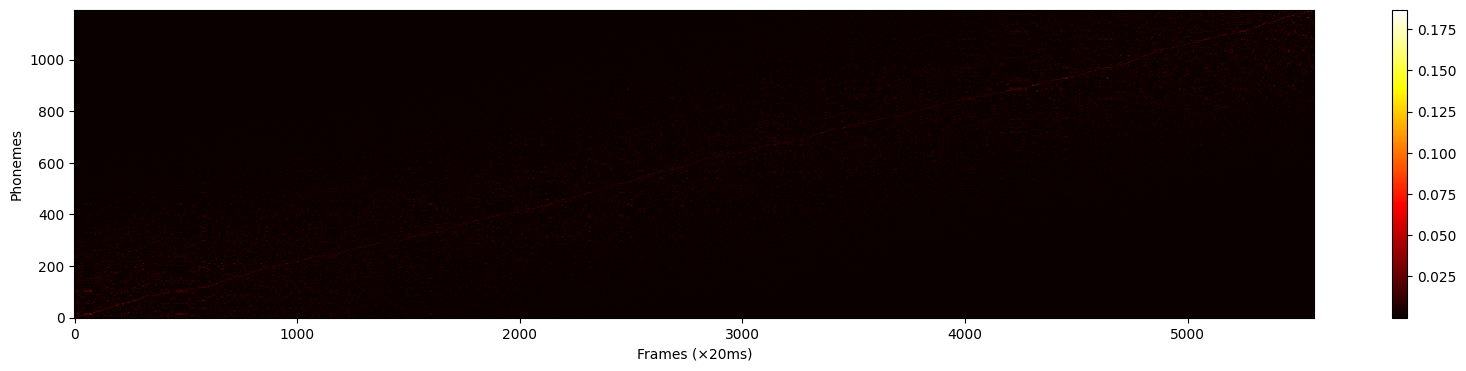

In [23]:
import matplotlib.pyplot as plt
import torch
import soundfile as sf
import numpy as np

# Run model on one file and plot A
key    = next(iter(results))
sample = results[key]
audio, _ = sf.read(os.path.join(audio_dir, sample["file"]))

# Run through model and plot
with torch.no_grad():
    logits, A, labels_clean = model(input_values, attention_mask)

A_np = A[0].cpu().numpy()   # (N, T)
plt.figure(figsize=(20, 4))
plt.imshow(A_np, aspect="auto", origin="lower", cmap="hot")
plt.xlabel("Frames (×20ms)")
plt.ylabel("Phonemes")
plt.colorbar()
plt.savefig("alignment_plot.png")

In [24]:
# Audio duration vs last hypothesis interval
key      = next(iter(results))
sample   = results[key]
audio, _ = sf.read(os.path.join(audio_dir, sample["file"]))
audio_dur = len(audio) / 16000

hyp_end   = sample["hyp_intervals"][-1]["end"] if sample["hyp_intervals"] else 0
print(f"Audio duration:    {audio_dur:.3f}s")
print(f"HYP last interval: {hyp_end:.3f}s")
print(f"Ratio:             {hyp_end/audio_dur:.3f}  (should be ~1.0)")


Audio duration:    290.229s
HYP last interval: 290.220s
Ratio:             1.000  (should be ~1.0)


In [25]:
audio, sr = sf.read("/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D0002.wav")
chunk_duration= 5 ,  # seconds — stay within training distribution
chunk_index=0,   
if audio.ndim > 1:
    audio = audio.mean(axis=1)
chunk_size  = int(5.0 * sr)
start       = 0 * chunk_size
chunk  = audio[start:start+chunk_size]
dur    = len(chunk) / sr
print(f"AlignmentVisualizationCallback: loaded chunk {chunk_index} "
      f"({dur:.1f}s) from {os.path.basename(audio_path)}")


AlignmentVisualizationCallback: loaded chunk (0,) (5.0s) from Rhap-M2005.wav


In [26]:

inputs = feature_extractor(
    chunk,
    sampling_rate        = 16000,
    return_tensors       = "pt",
    return_attention_mask = True,
)
input_values   = inputs.input_values.to(device)
attention_mask = inputs.attention_mask.to(device)

with torch.no_grad():
    outputs      = model.wav2vec2(input_values, attention_mask)
    X            = outputs.last_hidden_state
    logits       = model.ctc_head(X)
    labels_clean = model._ctc_decode_batch(logits)
    Y_emb        = model.phoneme_embed(labels_clean)
    A            = model.compute_alignment(X, Y_emb)


AttributeError: 'Wav2Vec2ForCTC_FS_REC' object has no attribute 'phoneme_embed'

In [27]:
A_np  = A[0].cpu().float().numpy()   # (N, T)
ids   = labels_clean[0].cpu().numpy()
N_act = int((ids != 0).sum())
A_np  = A_np[:N_act, :]              # trim padding

# Decode phoneme labels for y axis
phone_labels = [
    tokenizer.convert_ids_to_tokens(int(ids[i]))
    for i in range(N_act)
]

# Compute stats
frame_phoneme   = A_np.argmax(axis=0)
unique_used     = len(set(frame_phoneme))
dominant_pos    = np.bincount(frame_phoneme, minlength=N_act).argmax()
dominant_pct    = np.bincount(frame_phoneme, minlength=N_act).max() / A_np.shape[1] * 100
max_val         = A_np.max()


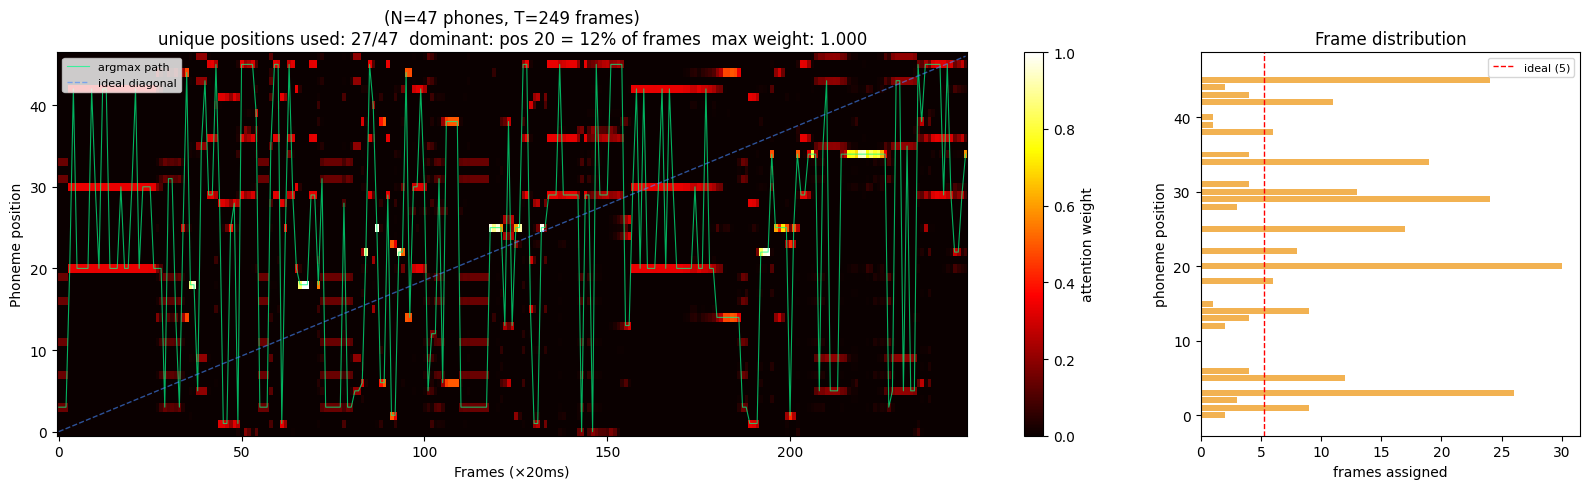

In [44]:
# Plot
fig, axes = plt.subplots(
    1, 2, figsize=(16, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

# Left — alignment heatmap
ax = axes[0]
im = ax.imshow(
    A_np, aspect="auto", origin="lower",
    cmap="hot", vmin=0, vmax=max_val
)
ax.set_xlabel("Frames (×20ms)")
ax.set_ylabel("Phoneme position")
ax.set_title(
    f"(N={N_act} phones, T={A_np.shape[1]} frames)\n"
    f"unique positions used: {unique_used}/{N_act}  "
    f"dominant: pos {dominant_pos} = {dominant_pct:.0f}% of frames  "
    f"max weight: {max_val:.3f}"
)
plt.colorbar(im, ax=ax, label="attention weight")

# Overlay argmax path
argmax_path = A_np.argmax(axis=0)
ax.plot(range(A_np.shape[1]), argmax_path,
        color="#00ff88", linewidth=0.8, alpha=0.7, label="argmax path")
ax.legend(loc="upper left", fontsize=8)

# Overlay diagonal prior line
T = A_np.shape[1]
diag_x = np.linspace(0, T-1, N_act)
diag_y = np.arange(N_act)
ax.plot(diag_x, diag_y, color="#4488ff",
        linewidth=1.0, linestyle="--", alpha=0.6, label="ideal diagonal")
ax.legend(loc="upper left", fontsize=8)

# Right — frame distribution (how many frames per phoneme)
ax2 = axes[1]
counts = np.bincount(frame_phoneme, minlength=N_act)
ax2.barh(range(N_act), counts, color="#EF9F27", alpha=0.8)
ax2.set_xlabel("frames assigned")
ax2.set_ylabel("phoneme position")
ax2.set_title("Frame distribution")
ax2.axvline(T / N_act, color="red", linestyle="--",
            linewidth=1, label=f"ideal ({T//N_act})")
ax2.legend(fontsize=8)

plt.tight_layout()